# Assignment Two — 2025

## Data Preprocessing
- Simple statistical evaluation of the data set;
- Identify the target variable(s);
- Identify if this is a regression or a classification task;
- Are there any missing data? What can you do about them?
- Which variables are relevant or irrelevant to the task?
- What type of validation/cross-validation procedure will you use? 
- Data visualisation.

In [97]:
# Install Package 
import numpy as np, seaborn as sns, matplotlib.pyplot as plt, pandas as pd, matplotlib as mpl
from numpy.random import normal

import math

# Data splitting and model evaluation
from sklearn.model_selection import train_test_split, KFold, cross_val_score    

from sklearn.linear_model import LinearRegression, LassoCV, Lasso, LogisticRegression

from sklearn.metrics import mean_squared_error, r2_score

from sklearn.preprocessing import  StandardScaler

from sklearn.pipeline import make_pipeline, Pipeline

from sklearn.impute import SimpleImputer

from sklearn.compose import ColumnTransformer


In [98]:
# Loading the data
data = pd.read_csv("Euro_6_latest.csv", 
                   encoding= 'latin1') # encoding = 'latin1' is required because in the dataset, 
                                       # there are special characters. Latin1 is an encoding for Western Europe. 

In [99]:
data.head()

,Manufacturer,Model,Description,Transmission,Manual or Automatic,Engine Capacity,Fuel Type,Powertrain,Engine Power (PS),Engine Power (Kw),Electric energy consumption Miles/kWh,wh/km,Maximum range (Km),Maximum range (Miles),Euro Standard,Diesel VED Supplement,Testing Scheme,WLTP Imperial Low,WLTP Imperial Medium,WLTP Imperial High,WLTP Imperial Extra High,WLTP Imperial Combined,WLTP Imperial Combined (Weighted),WLTP Metric Low,WLTP Metric Medium,WLTP Metric High,WLTP Metric Extra High,WLTP Metric Combined,WLTP Metric Combined (Weighted),WLTP CO2,WLTP CO2 Weighted,Equivalent All Electric Range Miles,Equivalent All Electric Range KM,Electric Range City Miles,Electric Range City Km,Emissions CO [mg/km],THC Emissions [mg/km],Emissions NOx [mg/km],THC + NOx Emissions [mg/km],Particulates [No.] [mg/km],RDE NOx Urban,RDE NOx Combined,Noise Level dB(A),Date of change
0,ABARTH,500e MY23/24,114kW Electric (VL),A1,Electric - Not Applicable,0.0,Electricity,Battery Electric Vehicle (BEV) / Pure Electric...,155.0,114.0,3.6,172.0,264.0,164.0,Euro 6-WLTP (for BEVs only),False,WLTP,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,NaN,223.0,359.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,68.0,17-Oct-24
1,ABARTH,500e MY23/24,114kW Electric (VH),A1,Electric - Not Applicable,0.0,Electricity,Battery Electric Vehicle (BEV) / Pure Electric...,155.0,114.0,3.3,187.0,244.0,152.0,Euro 6-WLTP (for BEVs only),False,WLTP,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,NaN,205.0,330.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,68.0,17-Oct-24
2,ABARTH,500e MY23/24,114kW Electric Convertible (VL),A1,Electric - Not Applicable,0.0,Electricity,Battery Electric Vehicle (BEV) / Pure Electric...,155.0,114.0,3.6,172.0,264.0,164.0,Euro 6-WLTP (for BEVs only),False,WLTP,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,NaN,223.0,359.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,68.0,17-Oct-24
3,ABARTH,500e MY23/24,114kW Electric Convertible (VH),A1,Electric - Not Applicable,0.0,Electricity,Battery Electric Vehicle (BEV) / Pure Electric...,155.0,114.0,3.3,187.0,244.0,152.0,Euro 6-WLTP (for BEVs only),False,WLTP,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,NaN,205.0,330.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,68.0,17-Oct-24
4,ABARTH,595 MY23,Turismo 1.4 Tjet 165 hp Manual (VL),M5,Manual,1368.0,Petrol,Internal Combustion Engine (ICE),165.0,121.0,0.0,NaN,NaN,NaN,Euro 6d,False,WLTP,28.8,43.3,47.0,47.0,40.6,0.0,9.8,6.5,6.0,6.0,7.0,0.0,157,0.0,NaN,NaN,NaN,NaN,688.0,66.0,28.0,NaN,NaN,60.0,60.0,69.0,17-Oct-24


In [100]:
print(f"Original data shape: {data.shape}")

Original data shape: (3702, 44)


In [101]:
data.dtypes 

Manufacturer                              object
Model                                     object
Description                               object
Transmission                              object
Manual or Automatic                       object
Engine Capacity                          float64
Fuel Type                                 object
Powertrain                                object
Engine Power (PS)                        float64
Engine Power (Kw)                        float64
Electric energy consumption Miles/kWh    float64
wh/km                                    float64
Maximum range (Km)                       float64
Maximum range (Miles)                    float64
Euro Standard                             object
Diesel VED Supplement                       bool
Testing Scheme                            object
WLTP Imperial Low                        float64
WLTP Imperial Medium                     float64
WLTP Imperial High                       float64
WLTP Imperial Extra 

Unique fuel types: ['Electricity' 'Petrol' 'Diesel' 'Electricity / Petrol' 'Petrol Electric'
 'Petrol / LPG' 'Diesel Electric' 'Electricity / Diesel']
Number of categories: 8


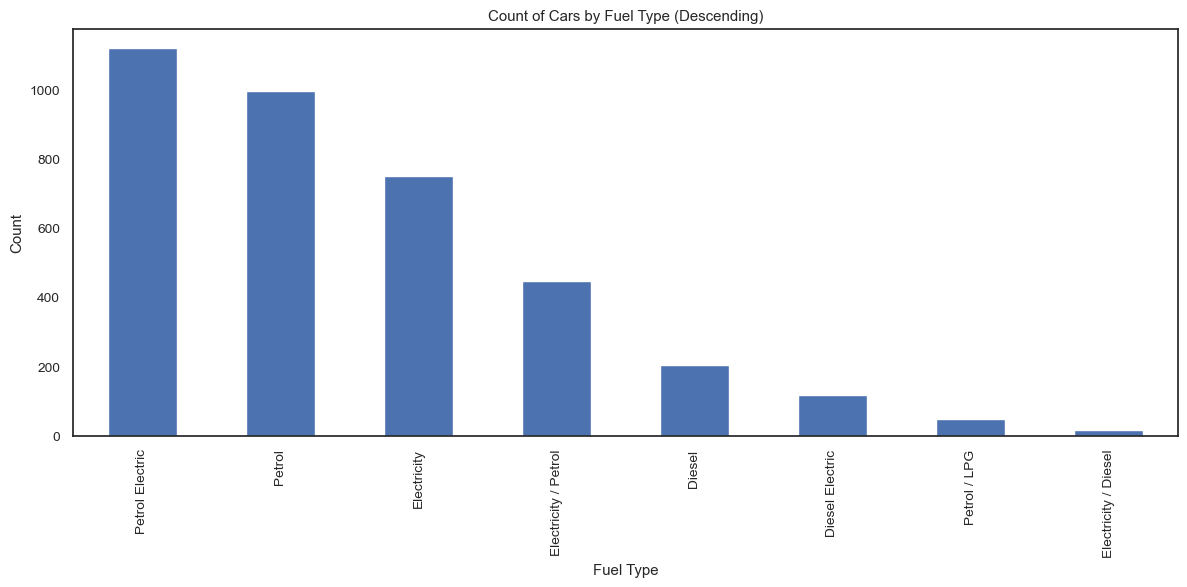

In [102]:
# Examine categorical data from Fuel Type column
fuel_type_categories = data["Fuel Type"].unique()
print(f"Unique fuel types: {fuel_type_categories}")
print(f"Number of categories: {len(fuel_type_categories)}")

fuel_type_counts = data["Fuel Type"].value_counts().reindex(fuel_type_categories, fill_value=0)
sorted_counts = fuel_type_counts.sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sorted_counts.plot(kind="bar")
plt.title("Count of Cars by Fuel Type (Descending)")
plt.ylabel("Count")
plt.xlabel("Fuel Type")
plt.tight_layout()
plt.show()

/var/folders/9z/h5wxsfgs1v9dg0bx0m5jvd0r0000gn/T/ipykernel_70190/2977562601.py:41: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.tight_layout()
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


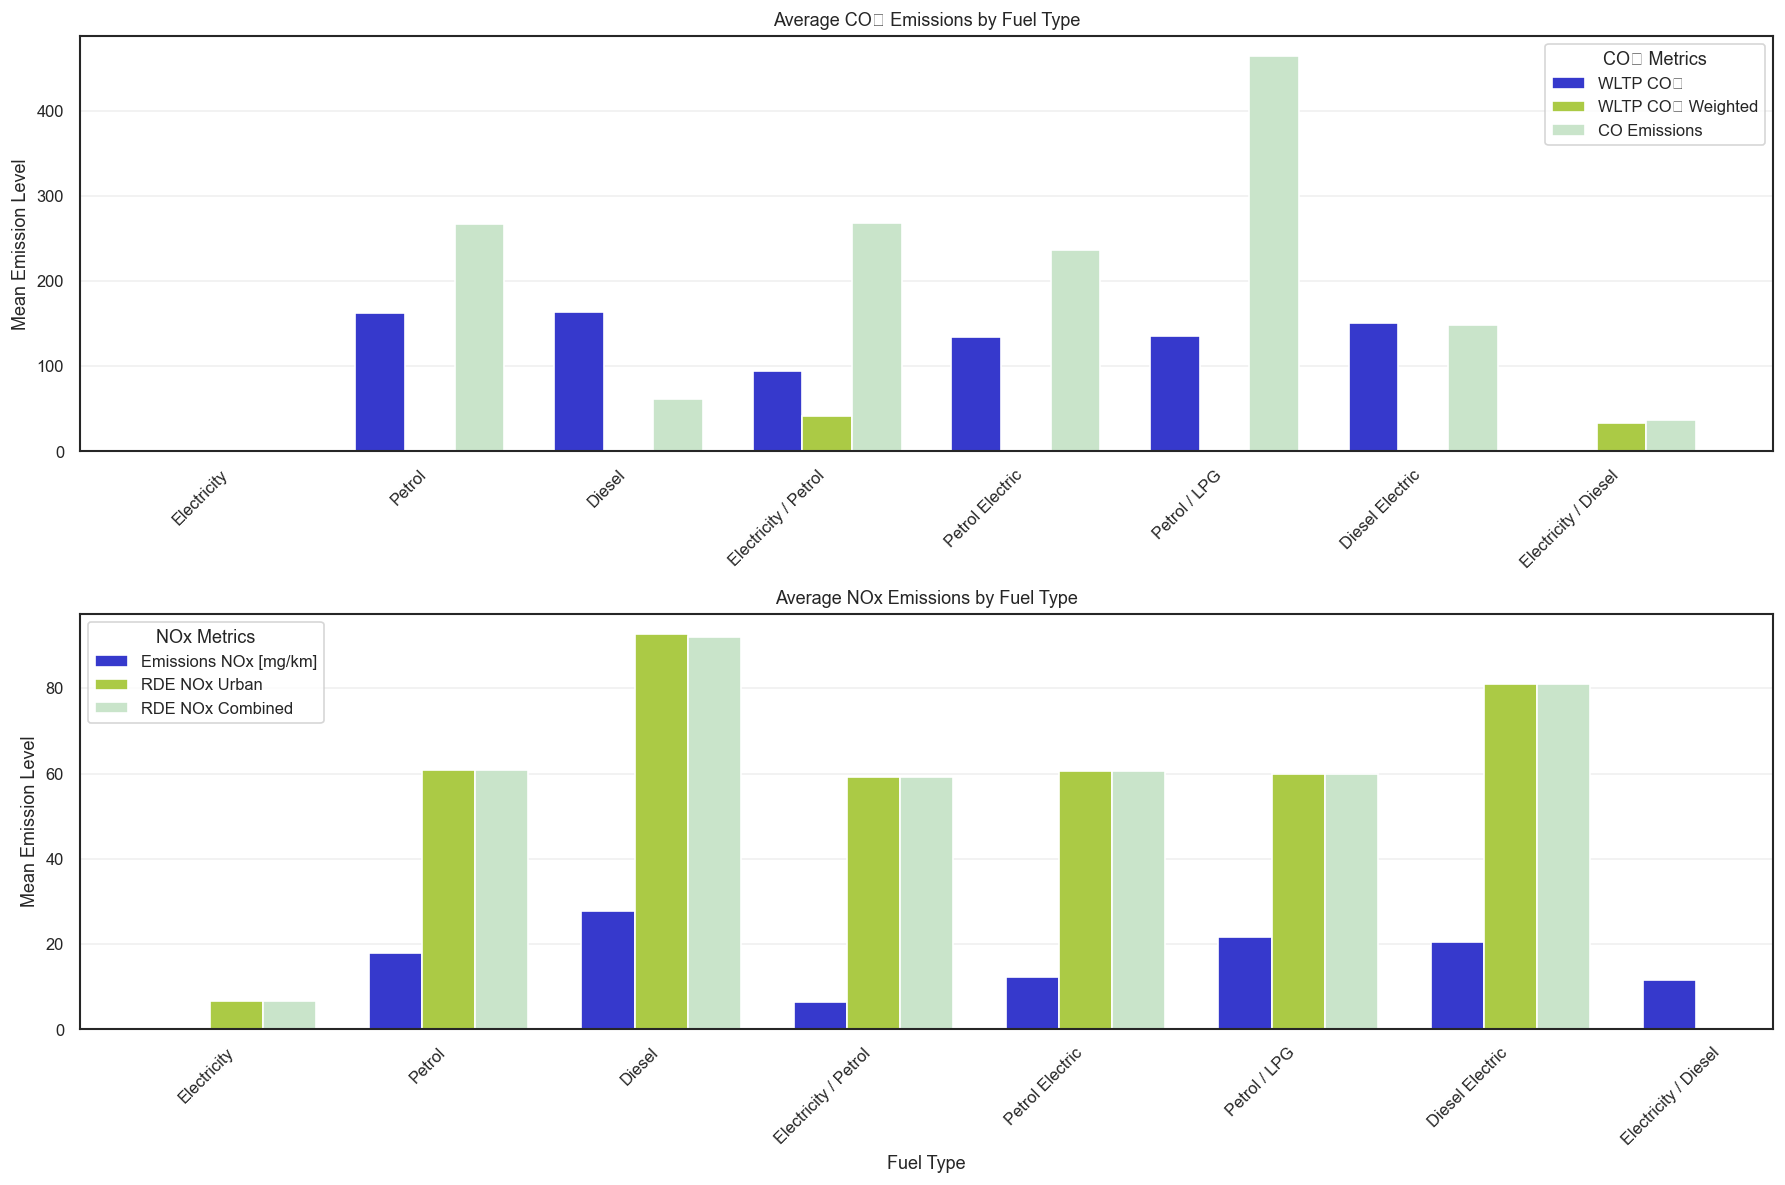

In [103]:
# Set up for CO2 Average Emission from each metric
metrics_CO2 = ["WLTP CO2", "WLTP CO2 Weighted", "Emissions CO [mg/km]"]
CO2_emission_means = data.groupby("Fuel Type")[metrics_CO2].mean().reindex(fuel_type_categories)

# Set up for NOx Average Emission from each metric
metrics_NOx = ["Emissions NOx [mg/km]", "RDE NOx Urban", "RDE NOx Combined"]
NOx_emission_means = data.groupby("Fuel Type")[metrics_NOx].mean().reindex(fuel_type_categories)

# set up for visualisation 
x = np.arange(len(CO2_emission_means.index))  # positions for each fuel type
width = 0.25  # width of each bar
fig, axs = plt.subplots(2,1, figsize=(15,10), dpi=120)

# Visualise CO2 Emisison on the top
axs[0].bar(x - width, CO2_emission_means["WLTP CO2"], width, label="WLTP CO₂", color="#3639CC")
axs[0].bar(x, CO2_emission_means["WLTP CO2 Weighted"], width, label="WLTP CO₂ Weighted", color="#ABCA45")
axs[0].bar(x + width, CO2_emission_means["Emissions CO [mg/km]"], width, label="CO Emissions", color="#C9E4CA")

axs[0].set_title("Average CO₂ Emissions by Fuel Type")
axs[0].set_xlabel("")  # top plot usually omits x-label
axs[0].set_ylabel("Mean Emission Level")
axs[0].set_xticks(x)
axs[0].set_xticklabels(CO2_emission_means.index, rotation=45, ha="right")
axs[0].legend(title="CO₂ Metrics")
axs[0].grid(axis="y", alpha=0.3)

# Visualise NOx Emisison in the bottom
axs[1].bar(x - width, NOx_emission_means["Emissions NOx [mg/km]"], width, label="Emissions NOx [mg/km]", color="#3639CC")
axs[1].bar(x, NOx_emission_means["RDE NOx Urban"], width, label="RDE NOx Urban", color="#ABCA45")
axs[1].bar(x + width, NOx_emission_means["RDE NOx Combined"], width, label="RDE NOx Combined", color="#C9E4CA")

axs[1].set_title("Average NOx Emissions by Fuel Type")
axs[1].set_xlabel("Fuel Type")
axs[1].set_ylabel("Mean Emission Level")
axs[1].set_xticks(x)
axs[1].set_xticklabels(NOx_emission_means.index, rotation=45, ha="right")
axs[1].legend(title="NOx Metrics")
axs[1].grid(axis="y", alpha=0.3)

# show
fig.tight_layout()
plt.show()

**Conclusion**
Pick WLTP CO2 due to: 
- have enough data accross different fuel types. (Despite CO emissions have more, but not common as CO2)
- WLTP CO2 (wegihts) is excluded because it lacked data distrbution accorss fuel types. 
- CO2 is more common to people understanding about gas emissions. 

Pick Emissions NOx [mg/km] because: 
- has difference mean across fuel type -> easier for comparison and prediction afterward.
- RDE NOx Urban and RDE NOx combined are nearly equal across different fuel types. Their mean values are not much different across fuel types. 

Based on the two graphs, eletric cars have no CO2 emissions, and low NOx emissions as well (given the source state that NOx emissions from eletric car are from their battery). Therefore, all of the eletric cars will be excluded from the datasets. 
Given the distribution, two datasets will be created based on their fuel types - fuel cars only (data_fuel), and hybrid cars only (data_hybrid).
Furthermore, since the target variables (WLTP CO2 and NO emissions) are not highly included in Eletricity /Diesel Fuel type, they will be removed from the data_hybrid

Based on the visualisation, following variables should be moved since they are not relevant


In [ ]:
removed_variables = [
    "Manufacturer", "Model", "Description",
    "Transmission", "Engine Power (Kw)", "Electric energy consumption Miles/kWh",
    "wh/km", "Maximum range (Km)", "Maximum range (Miles)",
    "Euro Standard", "Diesel VED Supplement", "Testing Scheme", 
    "WLTP CO2 Weighted", "Equivalent All Electric Range Miles", "Equivalent All Electric Range KM",
    "Electric Range City Miles", "Electric Range City Km", "Emissions CO [mg/km]",
    "THC Emissions [mg/km]", "THC + NOx Emissions [mg/km]", "Particulates [No.] [mg/km]",
    "RDE NOx Urban", "RDE NOx Combined", "Noise Level dB(A)", 
    "Date of change",
]
data = data.drop(columns=removed_variables)
print(f"Data shape after removing columns: {data.shape}")

Data shape after removing columns: (3702, 19)


In [105]:
# Define fuel type categories for each group
# electric_types = ["Electricity"]
hybrid_types = [
    "Electricity / Petrol", "Petrol Electric",
    "Diesel Electric"]

fuel_types = [
    "Petrol", "Diesel", "Petrol / LPG"
]

# Split the dataset
data_hybrid = data[data["Fuel Type"].isin(hybrid_types)]
data_fuel = data[data["Fuel Type"].isin(fuel_types)]
print(f"Hybrid cars: {data_hybrid.shape[0]} rows")
print(f"Fuel cars: {data_fuel.shape[0]} rows")

Hybrid cars: 1686 rows
Fuel cars: 1250 rows


Dataset shape before removing NA values: (1250, 19)


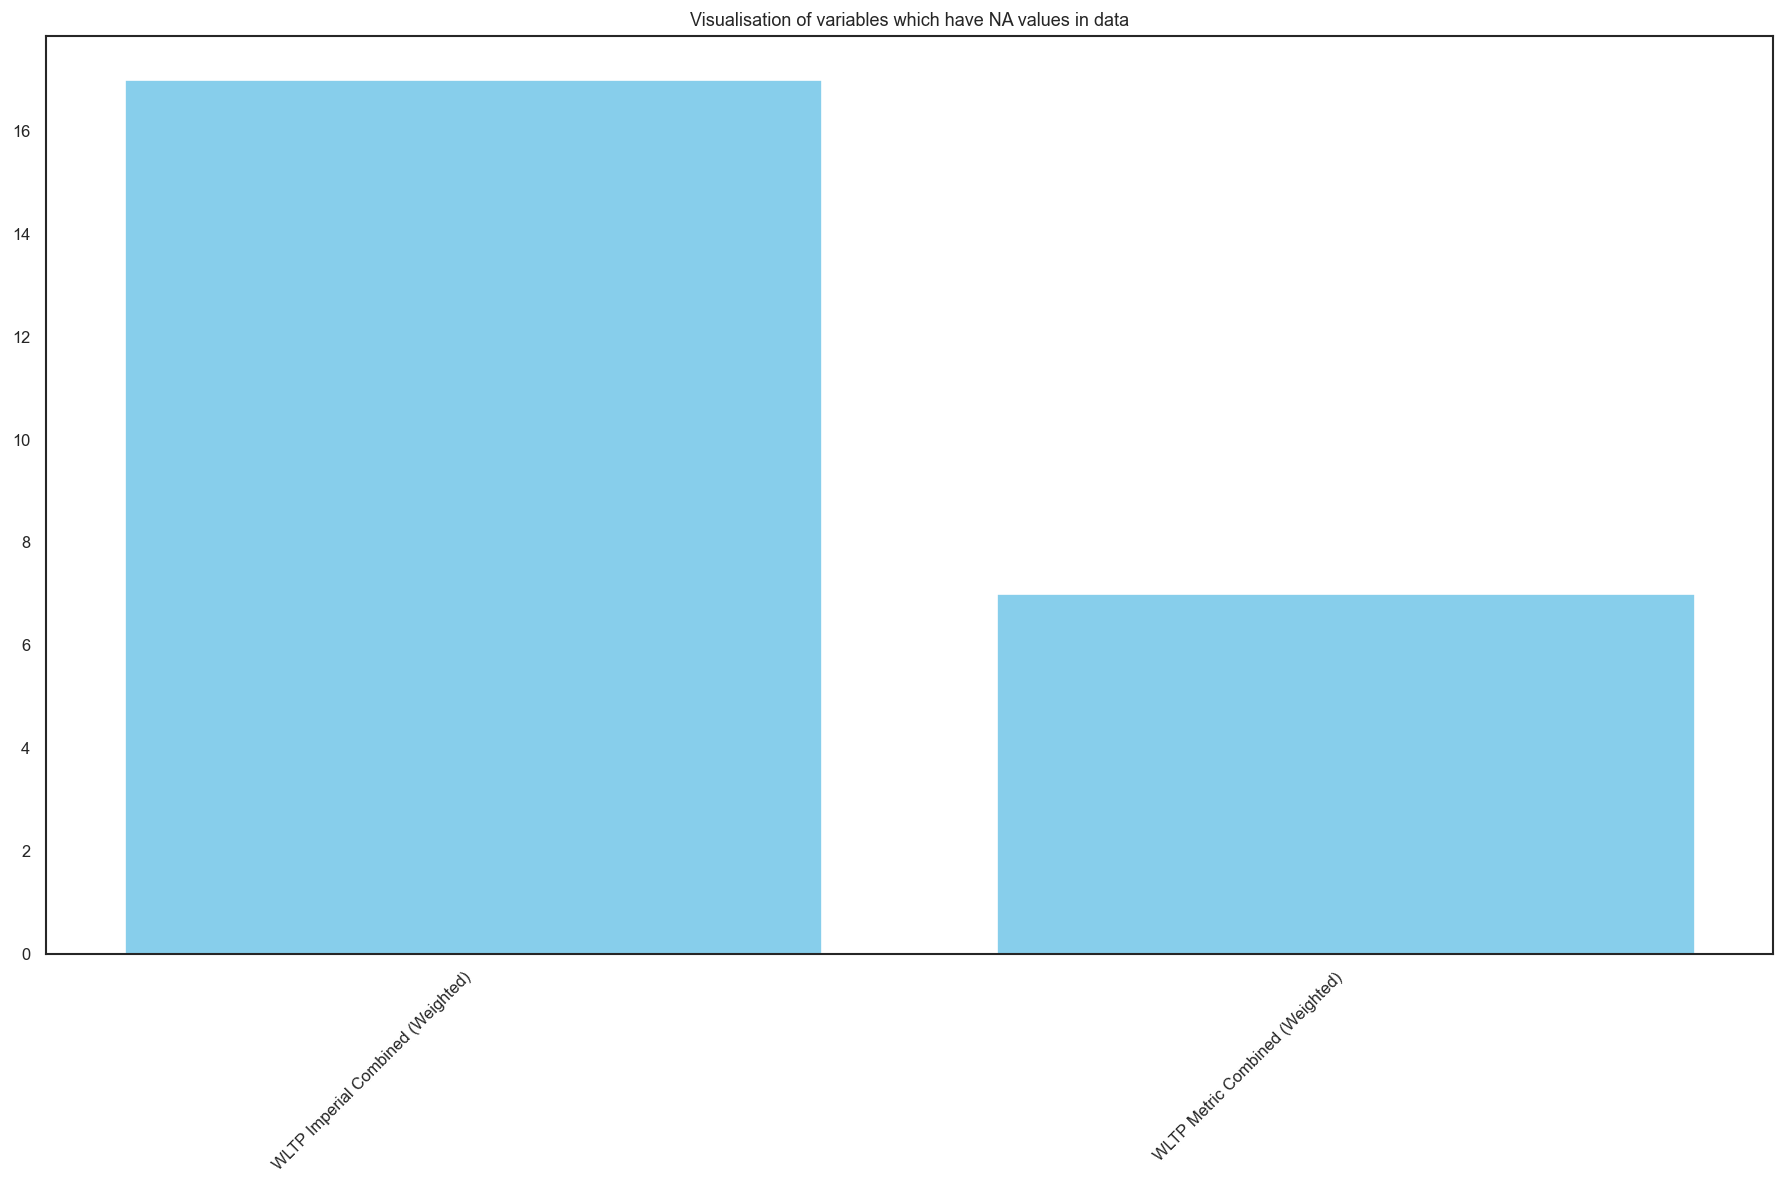

In [106]:
# this function count and visualise any columns that has NA values as bar chart 
def count_visualisa_na(data, data_name = "data"):
    NA_list = []
    col_name_list = []
    for i in range(data.shape[1]):
        col_name = data.columns[i]
        count = data[col_name].isna().sum()
        if count != 0: 
            NA_list.append(count)
            col_name_list.append(col_name)
                
    fig, axs = plt.subplots(1, 1, figsize=(15, 10), dpi=120, sharey=True)
    axs.bar(col_name_list, NA_list, color = "skyblue")
    plt.xticks(rotation = 45, ha = "right")
    plt.title(f'Visualisation of variables which have NA values in {data_name}')
    fig.tight_layout()
    plt.show()
    
#Check and remove NA values in fuel dataset
print("Dataset shape before removing NA values:", data_fuel.shape)
count_visualisa_na(data_fuel)


In [107]:
data_fuel = data_fuel.dropna()
print("Dataset shape after removing NA values:", data_fuel.shape)

Dataset shape after removing NA values: (1233, 19)


Dataset shape before removing NA values: (1686, 19)


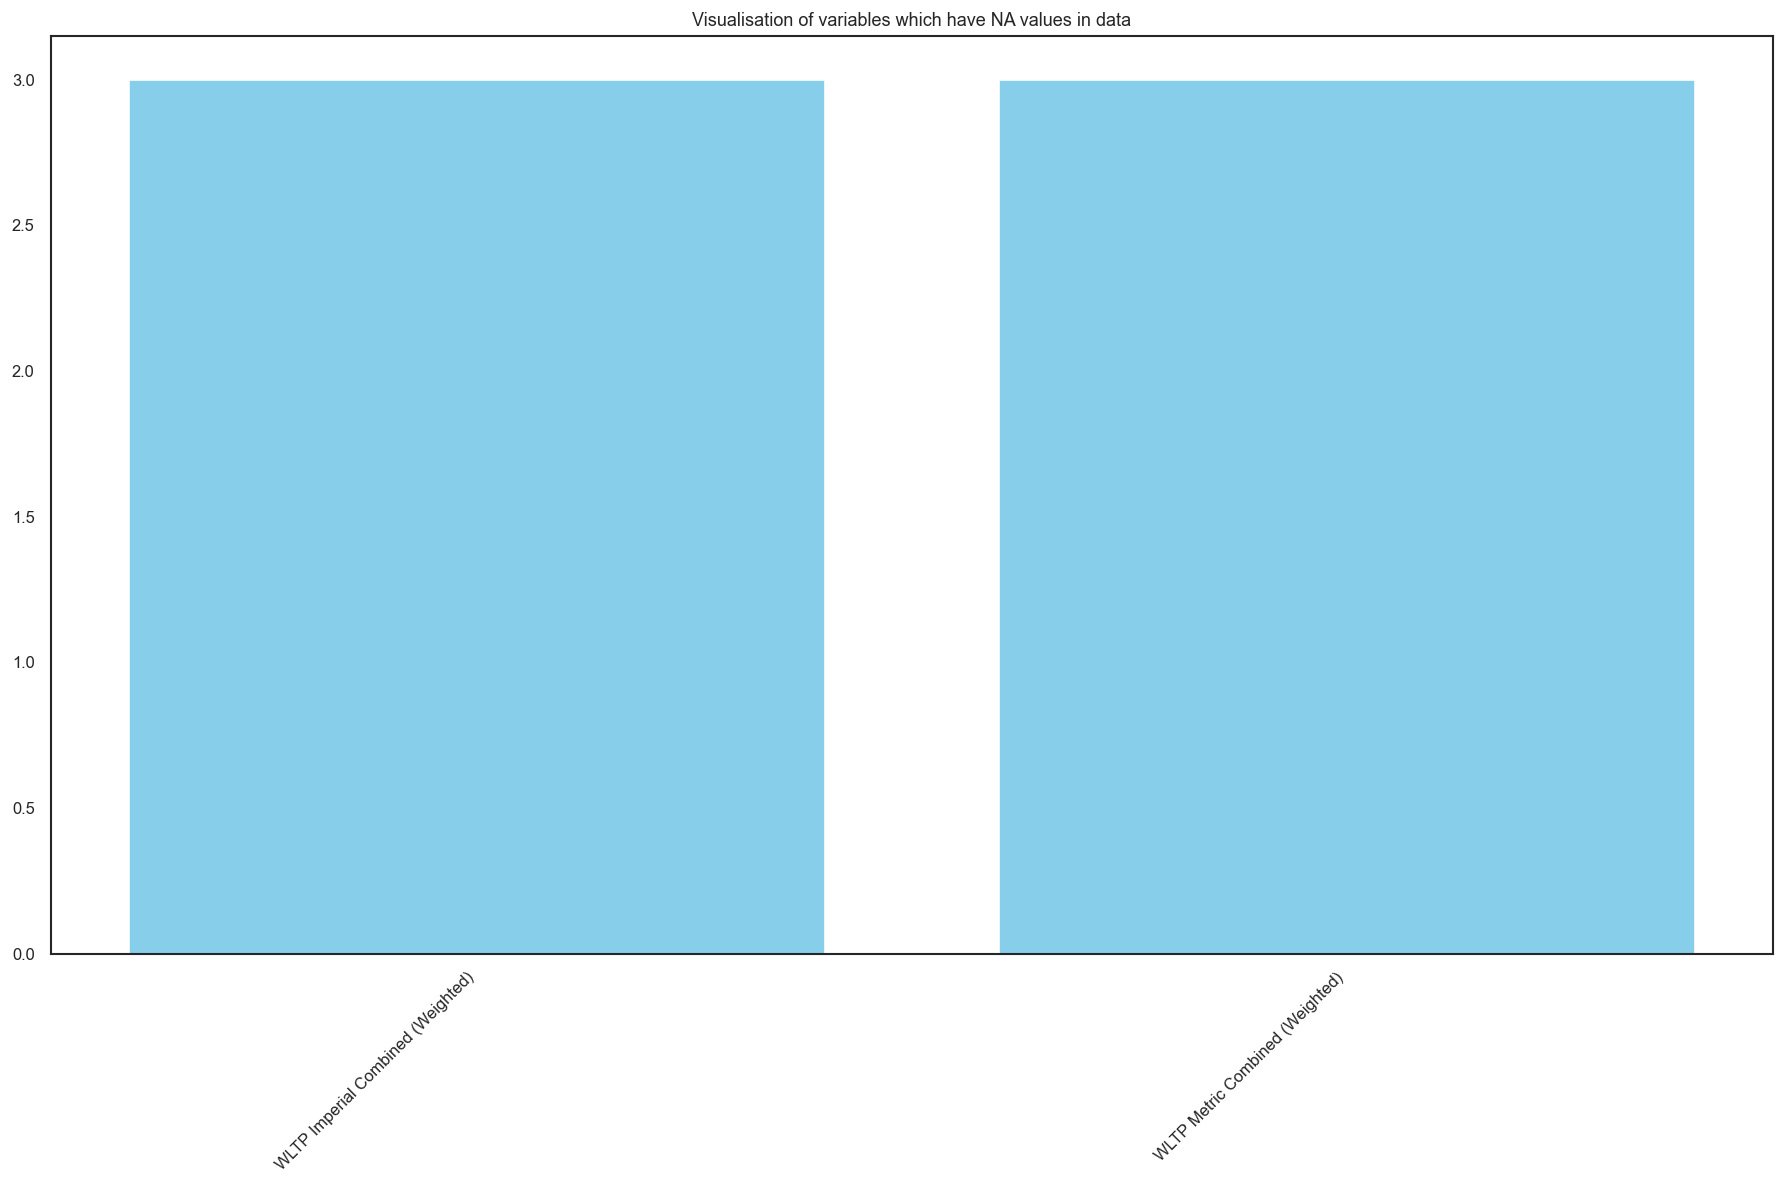

In [108]:
#Check and remove NA values in fuel dataset
print("Dataset shape before removing NA values:", data_hybrid.shape)
count_visualisa_na(data_hybrid)

In [109]:
data_hybrid = data_hybrid.dropna()
print("Dataset shape after removing NA values:", data_hybrid.shape)

Dataset shape after removing NA values: (1683, 19)


### Statistical Analysis

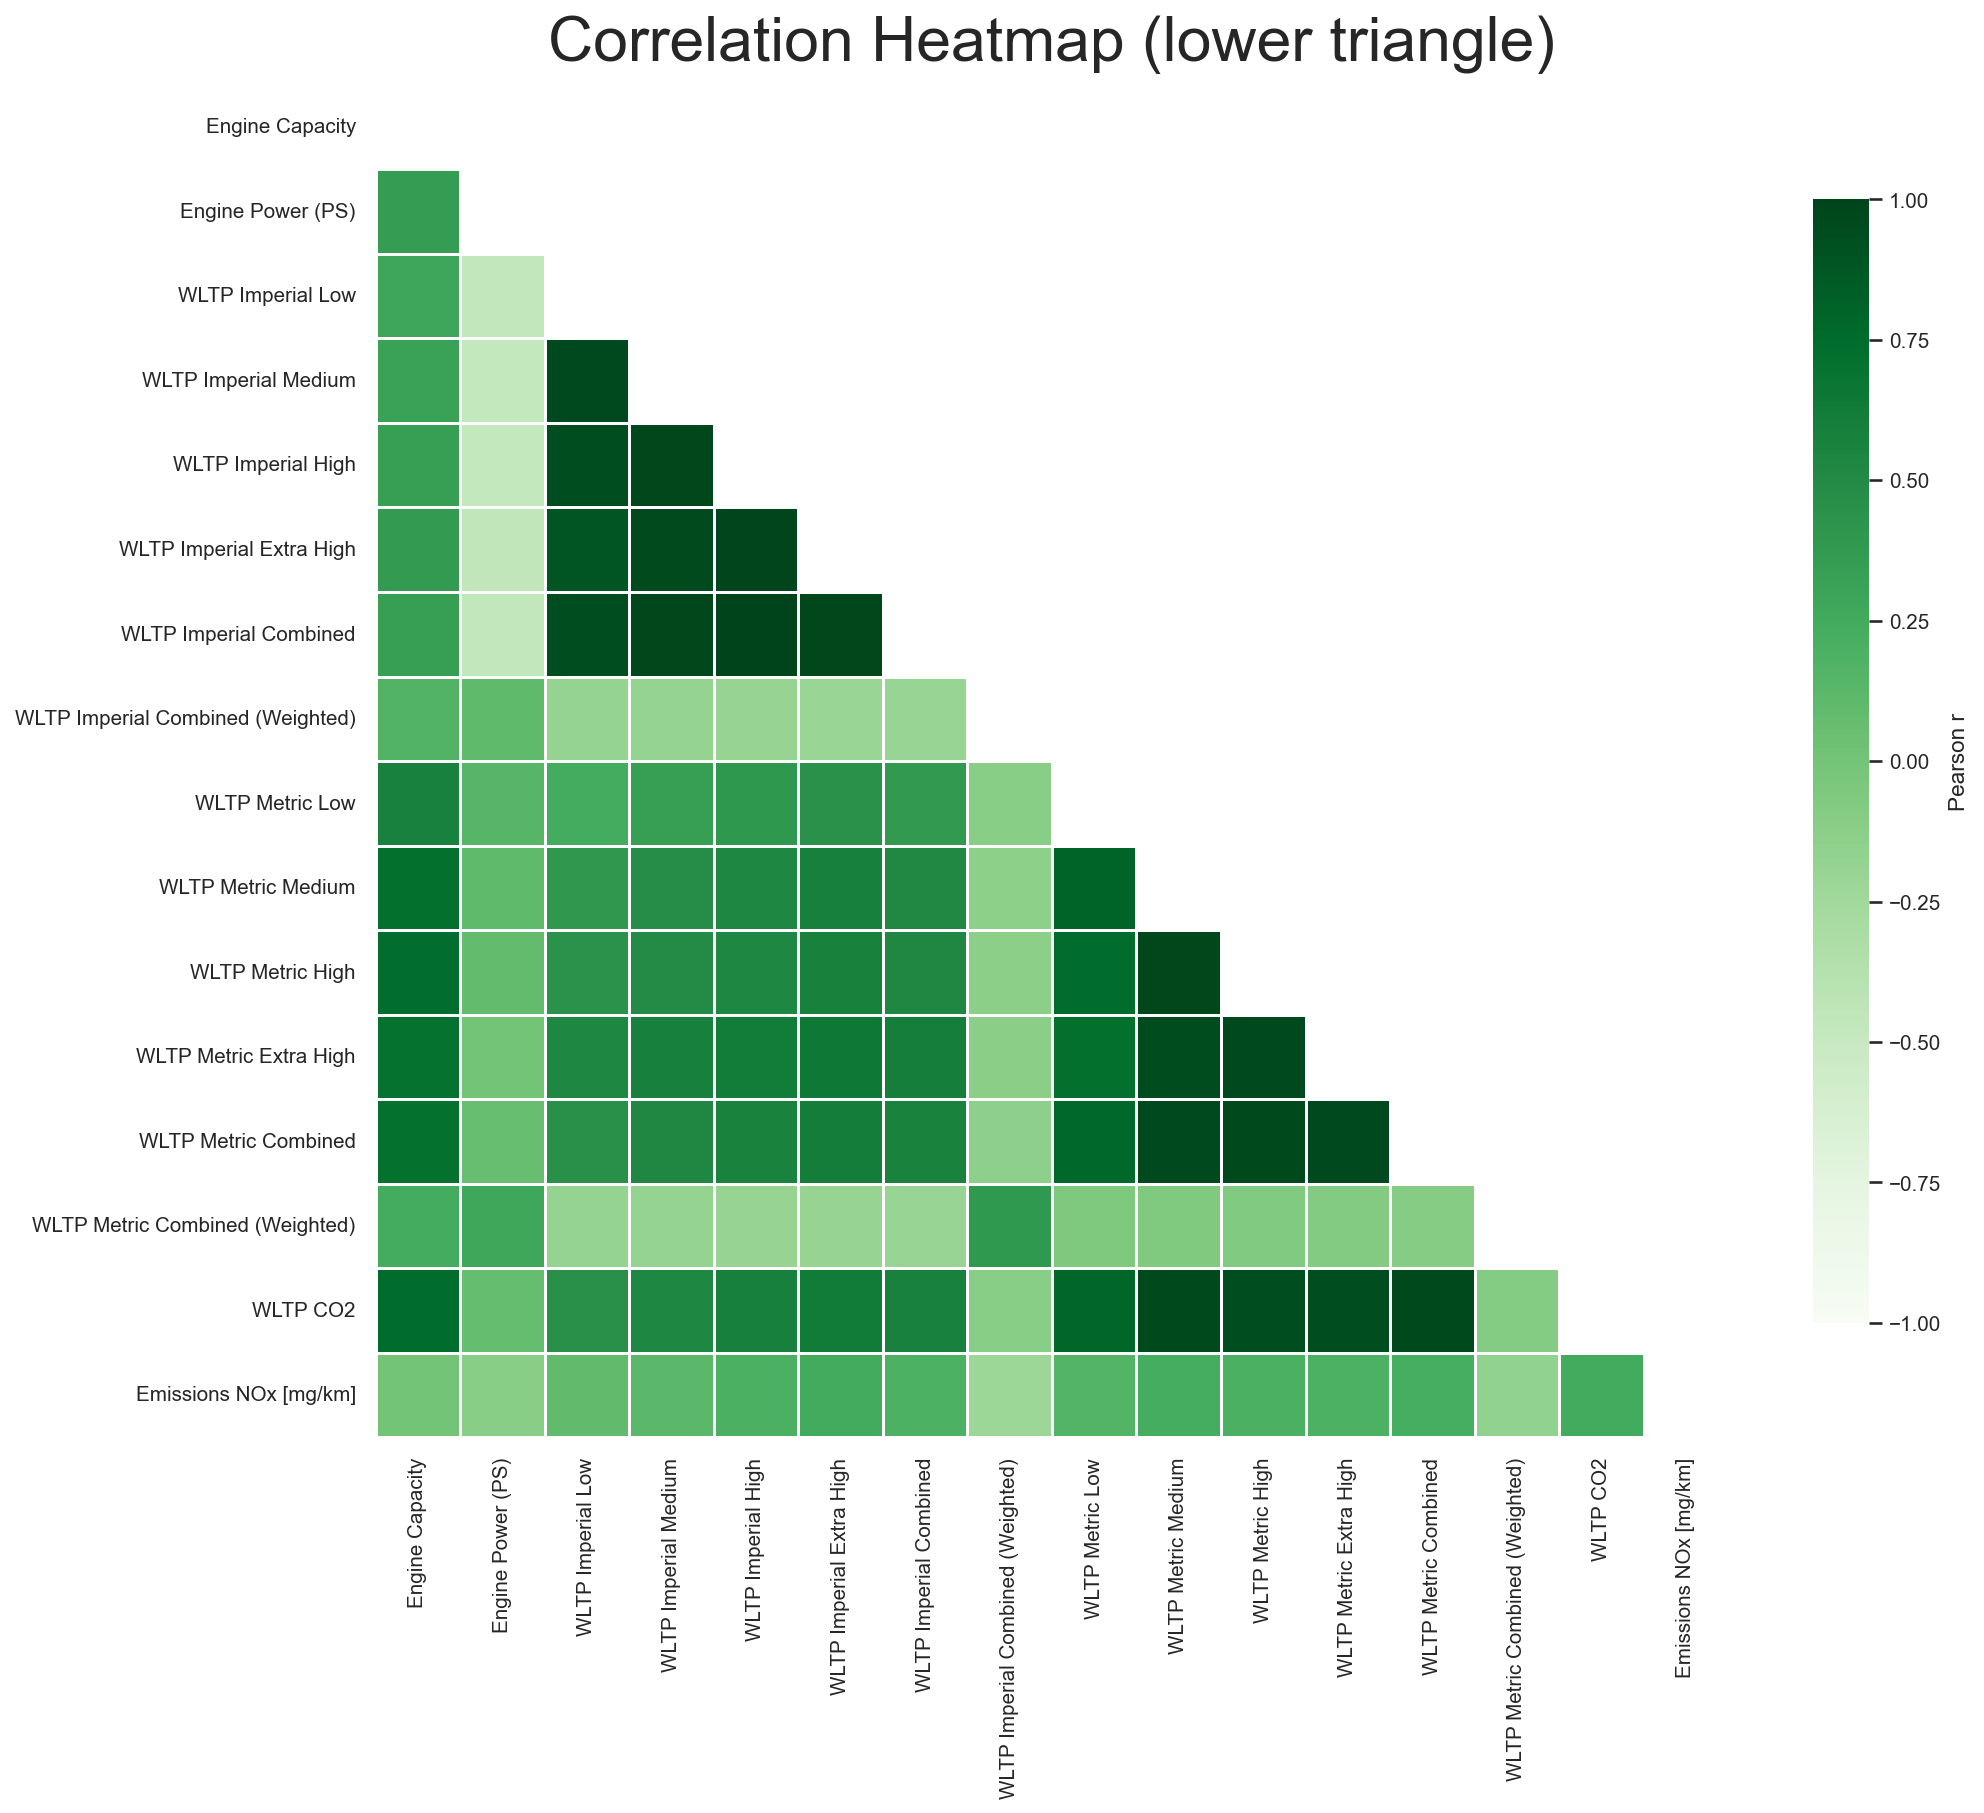

In [110]:
sns.set_theme(style="white", font_scale=0.9)  # smaller fonts

# Select only numeric columns for computing correlation
numeric_data = data.select_dtypes(include=[np.number])
corr = numeric_data.corr()

# mask the upper triangle (matrix is symmetric)
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 12), dpi=150)
ax = sns.heatmap(
    corr, mask=mask, cmap="Greens", vmin=-1, vmax=1, center=0,
    linewidths=.5, linecolor="white",
    cbar_kws=dict(shrink=.8, label="Pearson r"),
    annot=False,  # turn off numbers (too dense)
    square=True
)

ax.set_title("Correlation Heatmap (lower triangle)", fontsize = 30, pad=12)
plt.tight_layout()
plt.show()

Since it is over detailed to visualise the correlation matrix of all variables, only top 20 will be visualised to examine their correlations.

In [111]:
# Create a function to plot top Correlation values based on the target variable
def plot_nox_correlation(variable:str, data):
    # Set the target variable 
    target = variable

    # numeric-only correlation
    corr = data.select_dtypes(include='number').corr()

    # Extract correlations with target
    target_corr = corr[target].drop(labels=[target])

    # Sort by absolute correlation and take top 20
    top20 = target_corr.reindex(target_corr.abs().sort_values(ascending=False).index).head(20)

    # Plot
    plt.figure(figsize=(8, 7), dpi=150)
    bars = plt.barh(top20.index, top20.values, color='seagreen', edgecolor='black')

    # Add correlation values on bars
    for bar, value in zip(bars, top20.values):
        plt.text(value, bar.get_y() + bar.get_height()/2, f"{value:.2f}",
                ha='left' if value > 0 else 'right', va='center', fontsize=9)


    # Auto labeling based on Fuel Type column
    if data["Fuel Type"].isin(fuel_types).any():
        data_label = "Fuel Cars"
    elif data["Fuel Type"].isin(hybrid_types).any():
        data_label = "Hybrid Cars"
    else:
        data_label = "Dataset"


    plt.axvline(0, color='black', linewidth=0.8)
    plt.title(f"Top 20 Correlations with {target} from {data_label}", fontsize=15, pad=10)
    plt.xlabel("Correlation - Pearson r", fontsize=11)
    plt.ylabel("Variable", fontsize=11)
    plt.gca().invert_yaxis()  # highest correlation on top
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

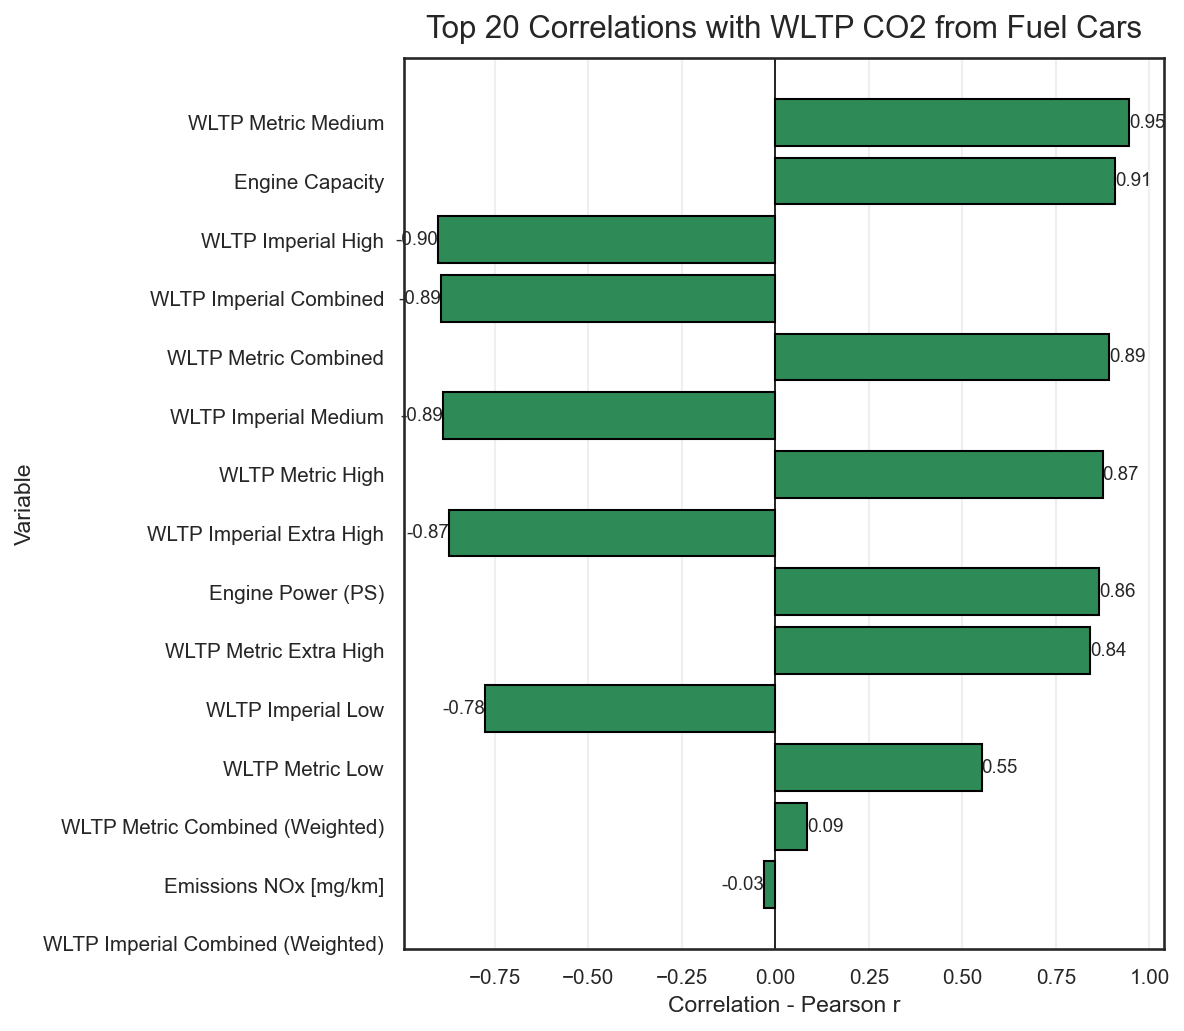

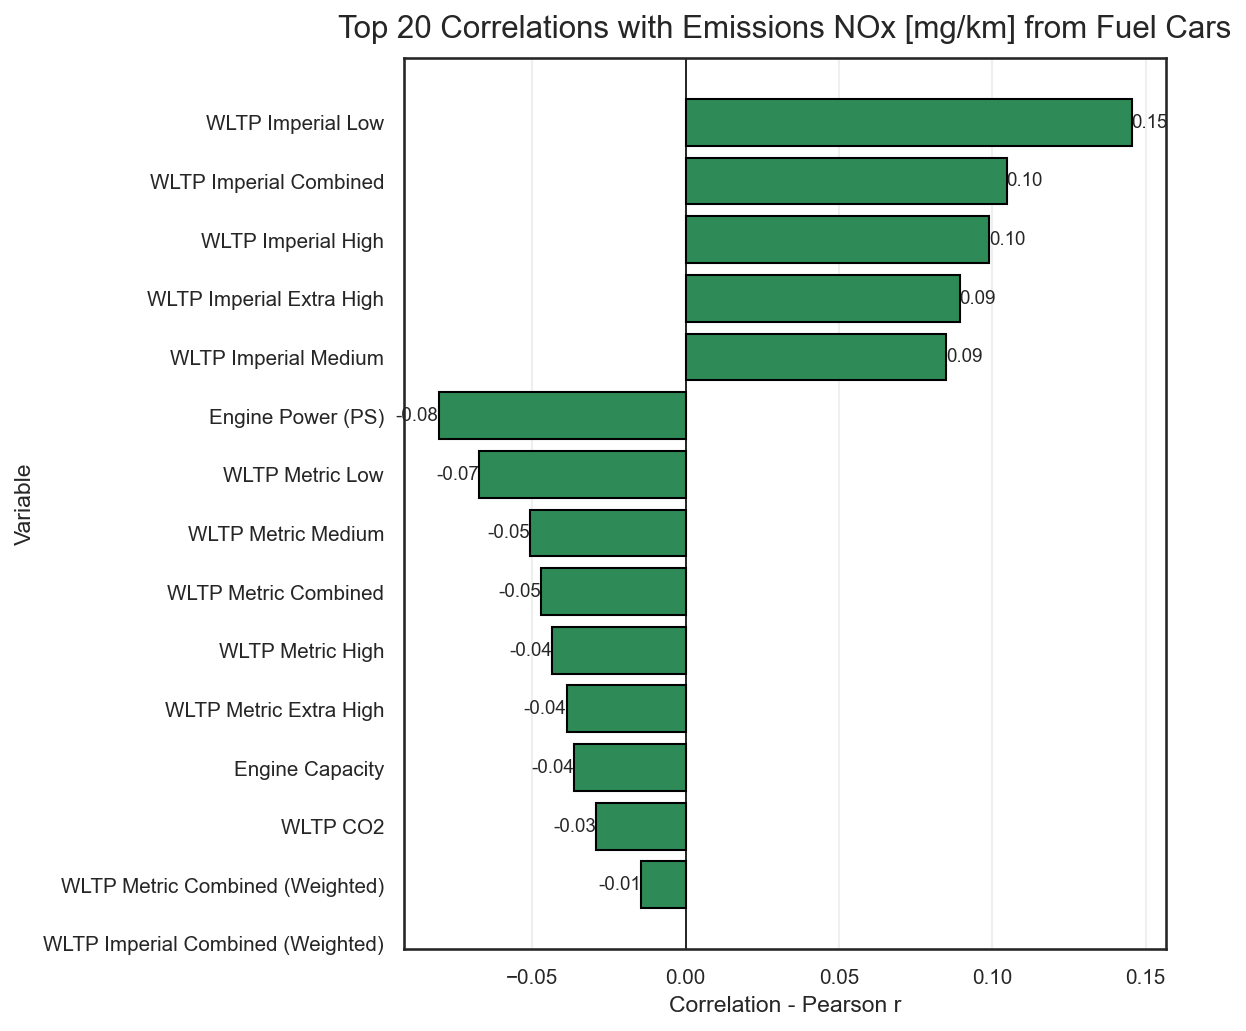

In [112]:
# -- Correlation Matrix for Fuel Cars
plot_nox_correlation("WLTP CO2", data_fuel)
plot_nox_correlation("Emissions NOx [mg/km]", data_fuel)

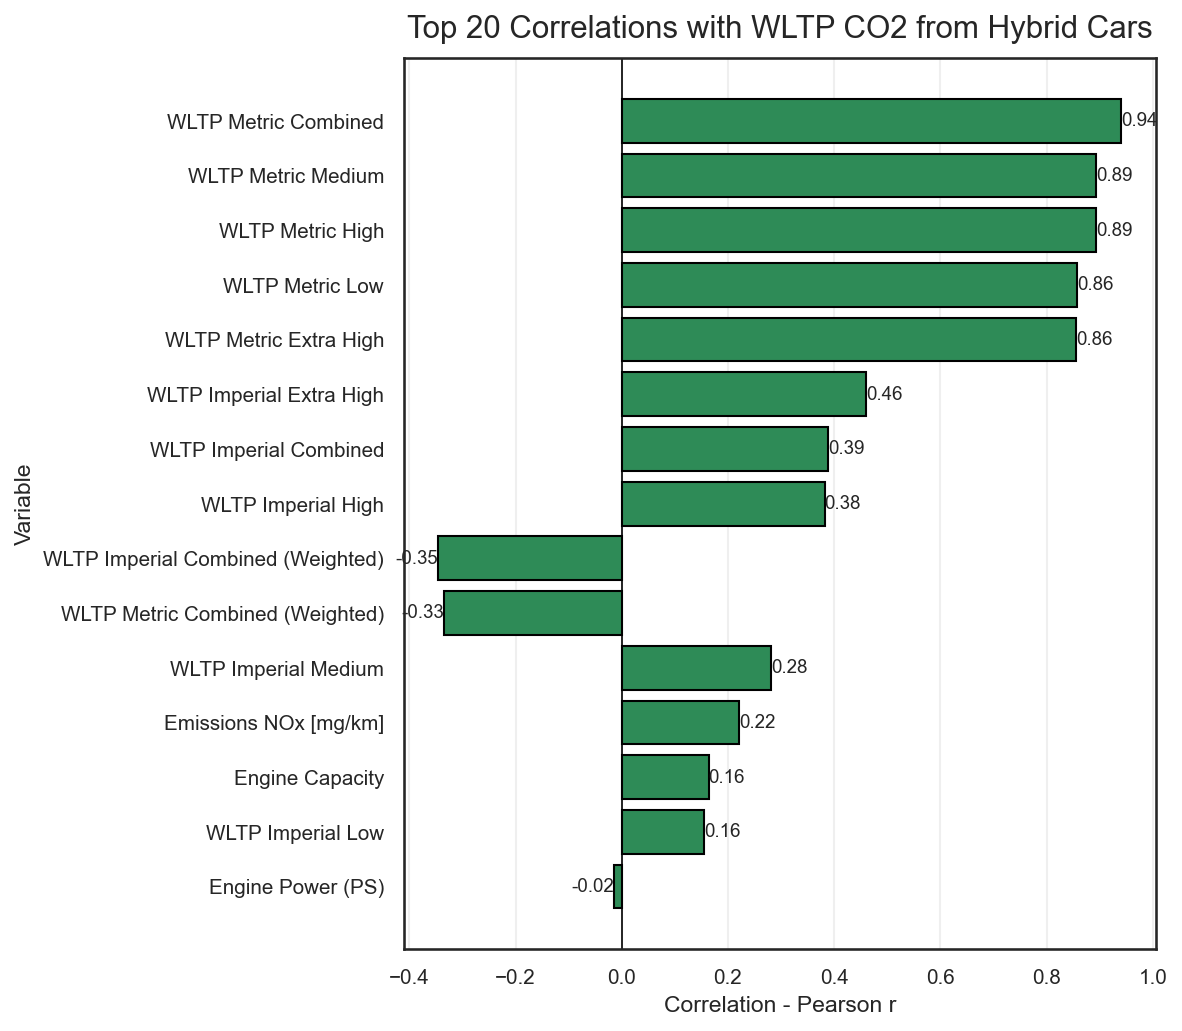

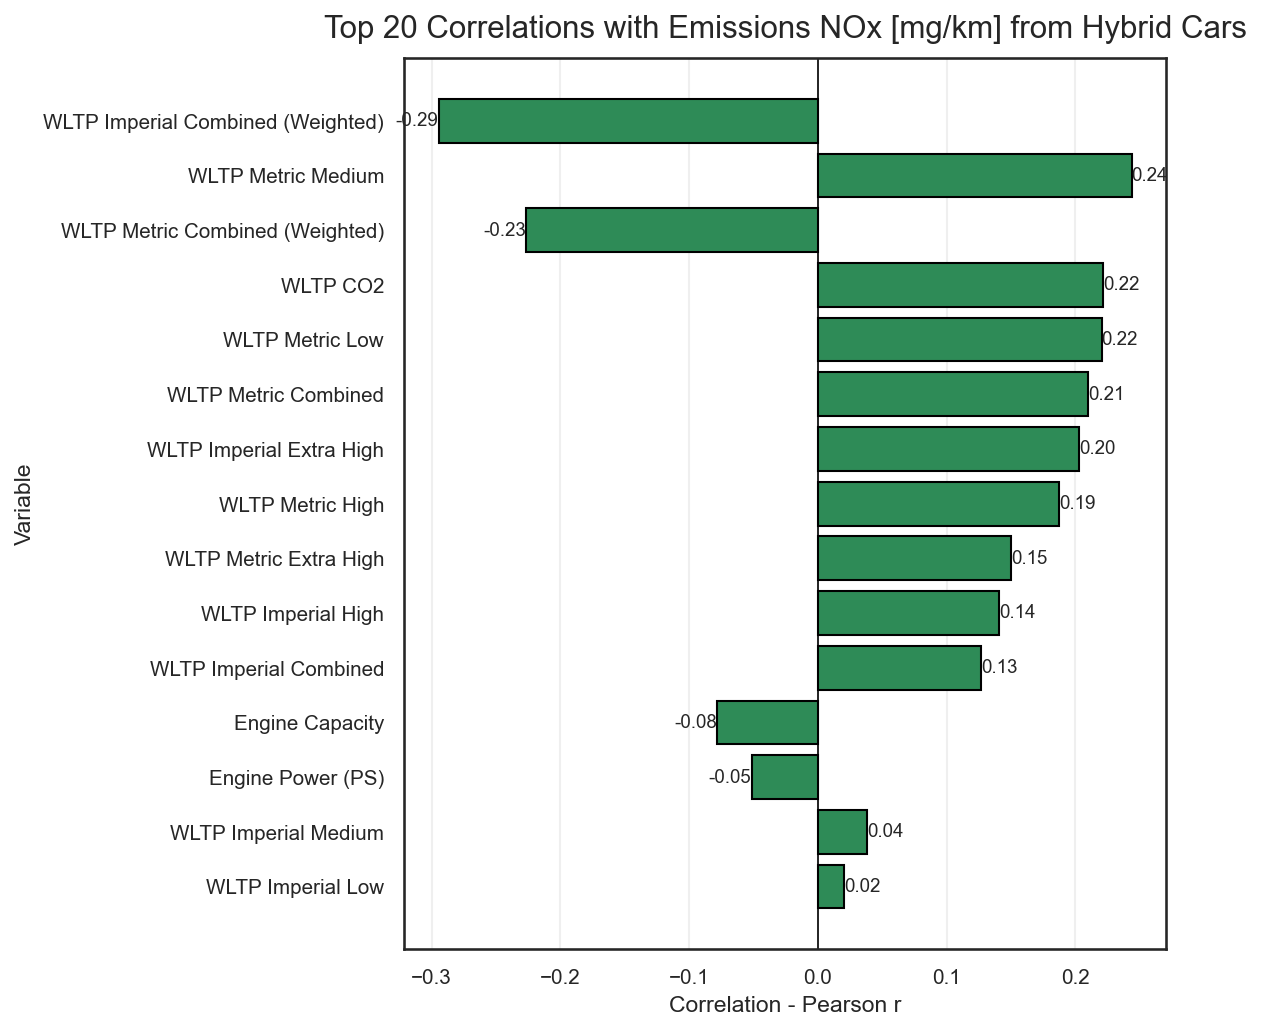

In [113]:
# -- Correlation Matrix for Hybrid Cars
plot_nox_correlation("WLTP CO2", data_hybrid)
plot_nox_correlation("Emissions NOx [mg/km]", data_hybrid)

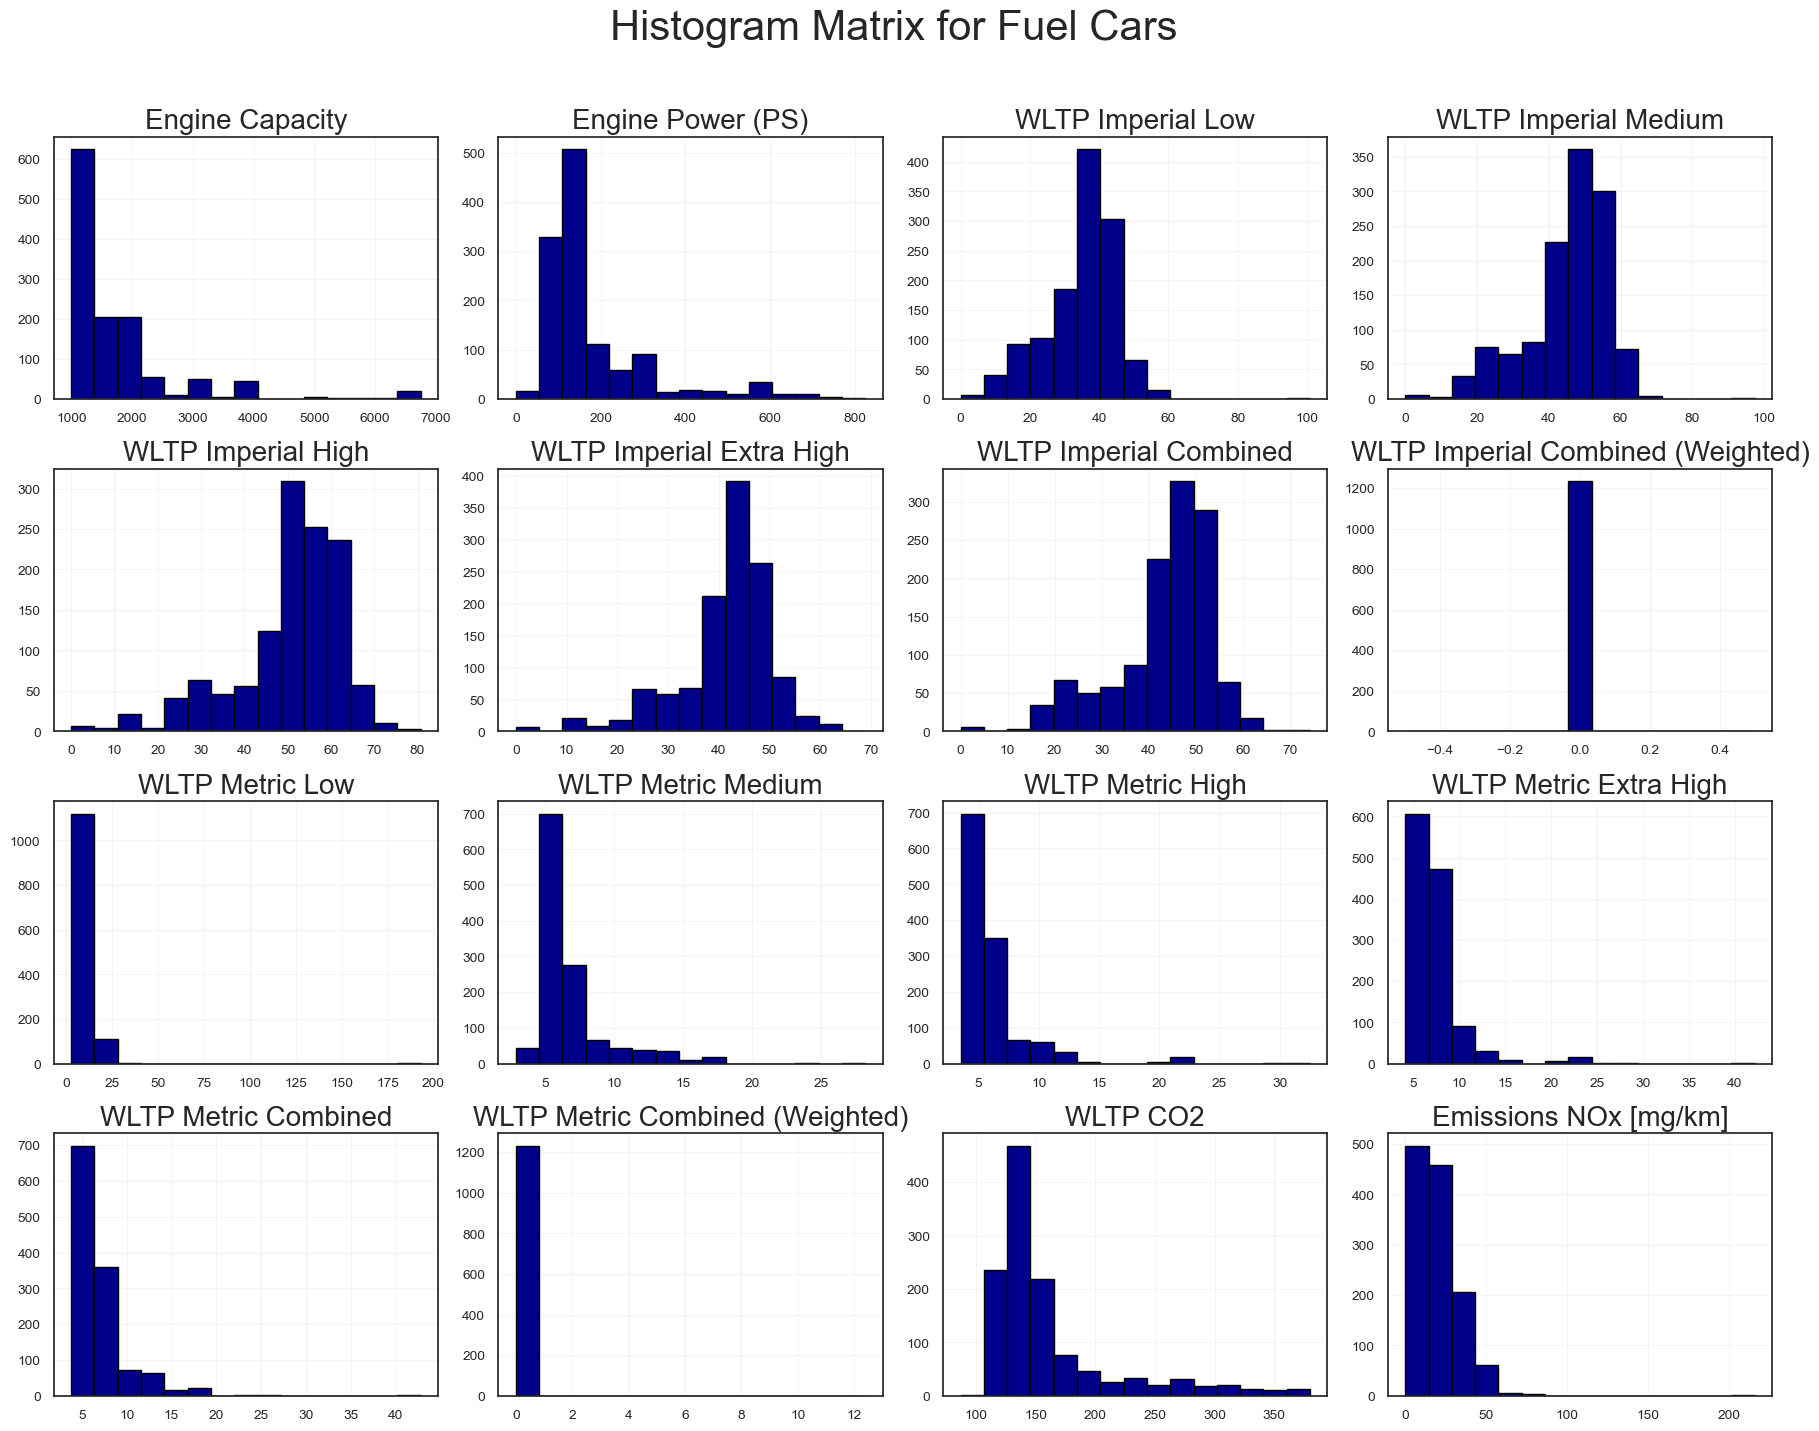

In [114]:
# -- Histogram Matrix for Fuel Cars --

# Set overall figure size (width, height)
axes = data_fuel.hist(
    figsize=(18, 14),  # larger matrix
    bins=15, # adjust bin count
    color='darkblue',
    edgecolor='black',
    grid=False
)

# Loop over all subplots to format text and labels
for ax in axes.flatten():
    # Bigger titles and smaller axis labels
    ax.set_title(ax.get_title(), fontsize=20)
    ax.set_xlabel(ax.get_xlabel(), fontsize=10)
    ax.set_ylabel(ax.get_ylabel(), fontsize=10)

    ax.grid(alpha=0.3, linewidth=0.5) # thin gridlines for readability

plt.suptitle("Histogram Matrix for Fuel Cars", fontsize=30, y=1.02)
plt.tight_layout()
plt.show()


Remove WLTP Imperial Combined (Weighted) and WLTP Metric Combined (Weighted) due to their unsual distribution.

In [115]:
# Remove irrelevant columns for regression task
data_fuel = data_fuel.drop(columns=["WLTP Imperial Combined (Weighted)", "WLTP Metric Combined (Weighted)"])
data_fuel.shape

(1233, 17)

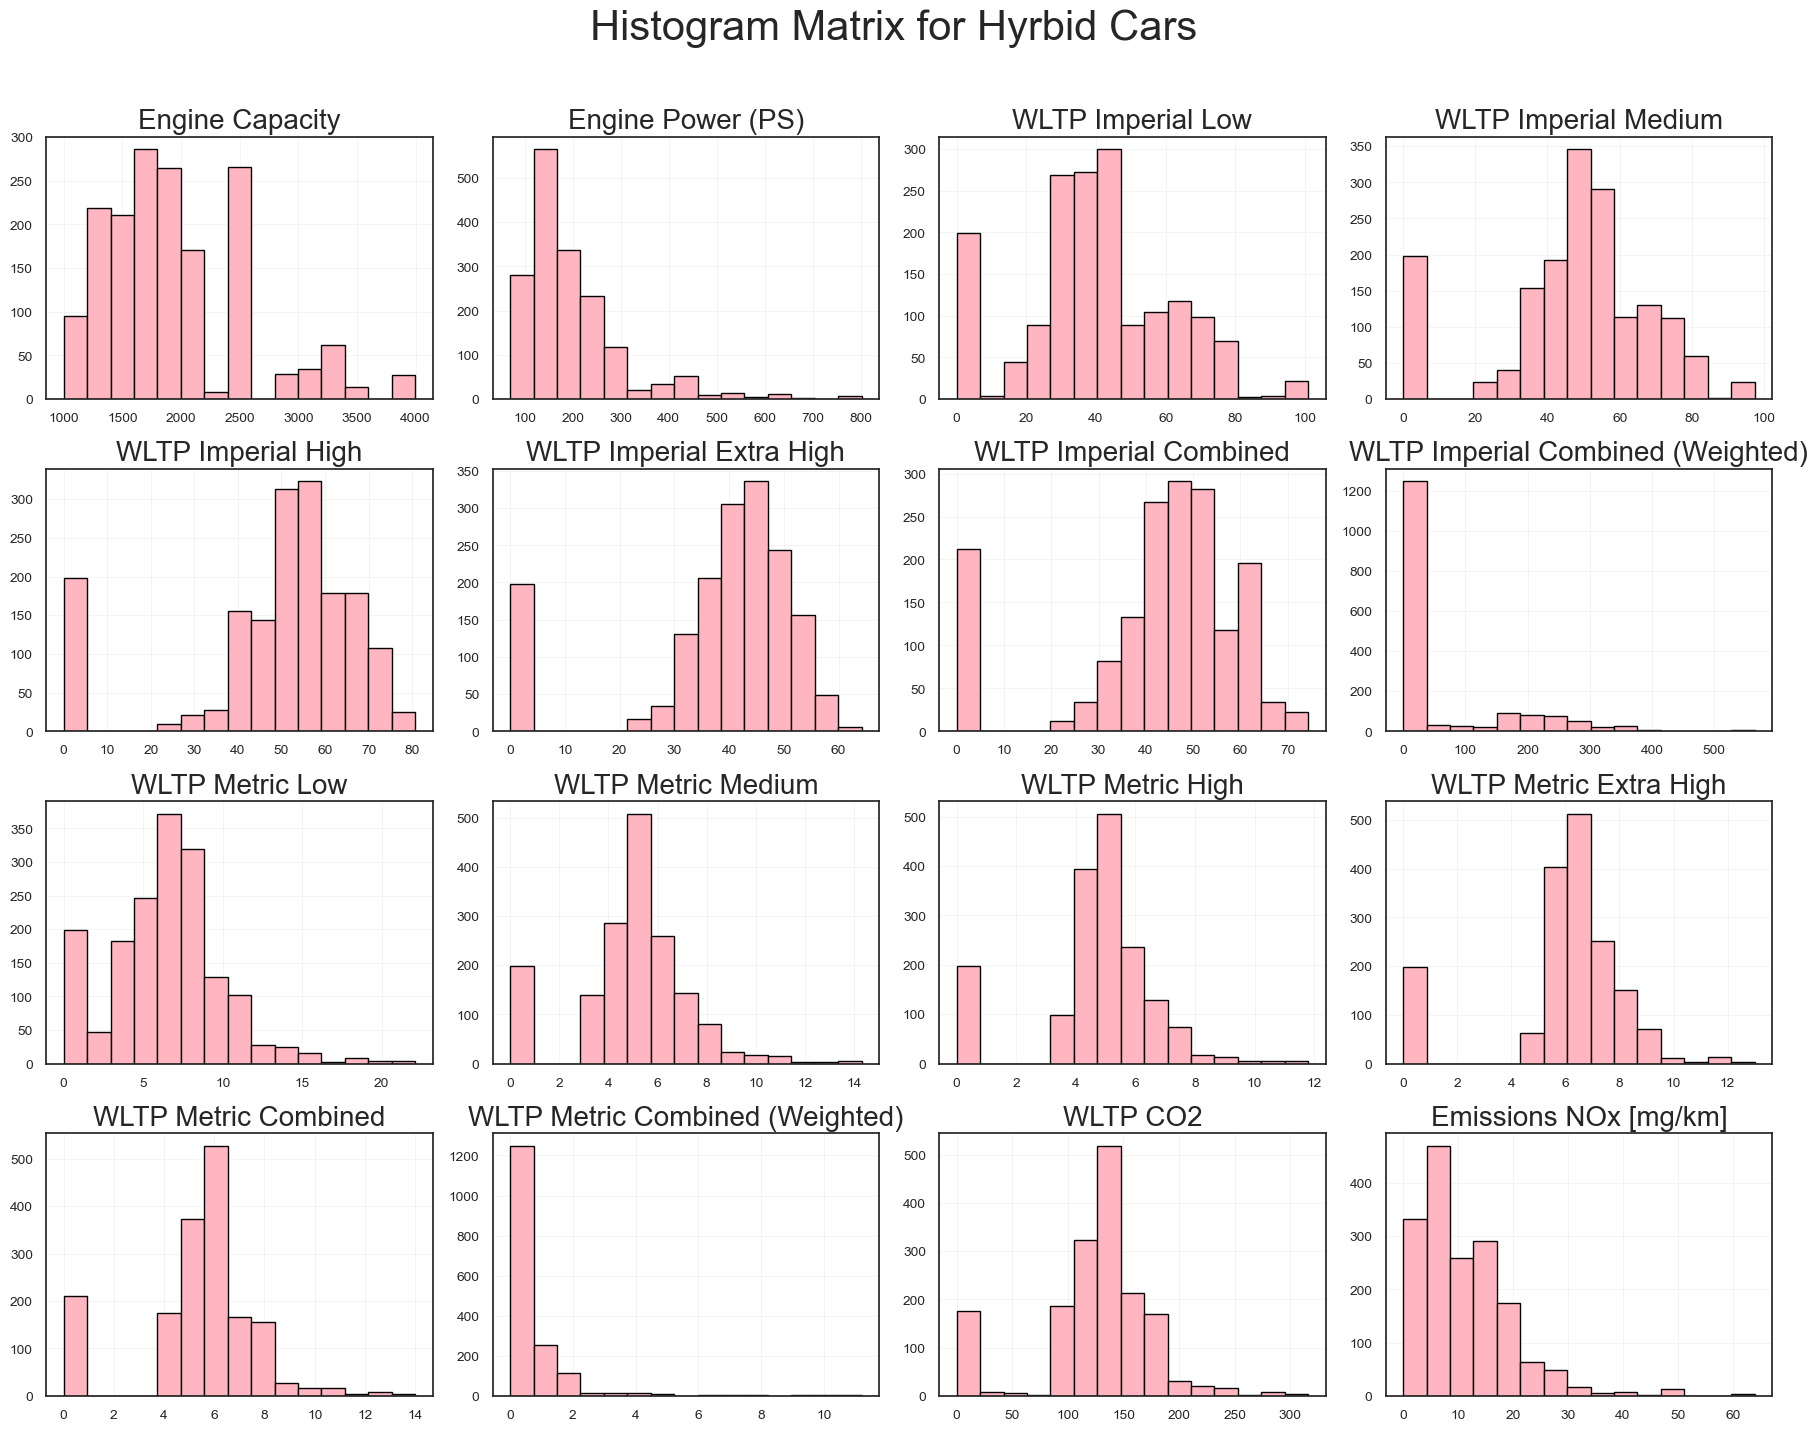

In [116]:
# -- Histogram Matrix for Hyrbid Cars --

# Set overall figure size (width, height)
axes = data_hybrid.hist(
    figsize=(18, 14),  # larger matrix
    bins=15, # adjust bin count
    color='lightpink',
    edgecolor='black',
    grid=False
)

# Loop over all subplots to format text and labels
for ax in axes.flatten():
    # Bigger titles and smaller axis labels
    ax.set_title(ax.get_title(), fontsize=20)
    ax.set_xlabel(ax.get_xlabel(), fontsize=10)
    ax.set_ylabel(ax.get_ylabel(), fontsize=10)

    ax.grid(alpha=0.3, linewidth=0.5) # thin gridlines for readability

plt.suptitle("Histogram Matrix for Hyrbid Cars", fontsize=30, y=1.02)
plt.tight_layout()
plt.show()

### The validation of datasets

In [134]:
# Data Splitting Function
def data_split(target: str, data: pd.DataFrame, random_state: int = 42):
    assert target in data.columns, f"Target '{target}' not in dataframe."
    # Split X/y
    X = data.drop(columns=[target])
    y = data[target]
    
    # Simple numeric imputation (if there are any remaining NaNs)
    X = X.fillna(X.mean(numeric_only=True)).fillna(0)
    
    # 80 / 20 split, then 10 / 10 from the 20
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.20, 
                                                         random_state=random_state)
    X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.50, 
                                                     random_state=random_state)
     
    # Encode categorical variables as dummy/one-hot columns
    X_train = pd.get_dummies(X_train, drop_first=True, dtype=float)
    X_val   = pd.get_dummies(X_val,   drop_first=True, dtype=float)
    X_test  = pd.get_dummies(X_test,  drop_first=True, dtype=float)

    train_cols = X_train.columns
    X_val  = X_val.reindex(columns=train_cols, fill_value=0)
    X_test = X_test.reindex(columns=train_cols, fill_value=0)

    # Scaling the X data
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)
     
    return {
         "X_train": X_train,
         "X_val": X_val,
         "X_test": X_test,
         "y_train": y_train,
         "y_val": y_val,
         "y_test": y_test
     } 

# -- Reusable function for 10-fold CV and evaluation (regression task)--
def tenfold_dataValidation(target: str, data: pd.DataFrame, plot: bool = True, random_state: int = 42):
    assert target in data.columns, f"Target '{target}' not in dataframe."

    splits = data_split(target, data)

    # Access the data
    X_train = splits["X_train"]
    X_val   = splits["X_val"]
    X_test  = splits["X_test"]
    y_train = splits["y_train"]
    y_val   = splits["y_val"]
    y_test  = splits["y_test"]

    linear_model = LinearRegression()

    # 10-fold CV on TRAIN ONLY (neg MSE -> MSE)
    kf = KFold(n_splits=10, shuffle=True, random_state=random_state)
    mse_scores = -cross_val_score(linear_model, X_train, y_train, cv=kf,
                              scoring="neg_mean_squared_error", n_jobs=-1)
    print("10-fold CV MSE scores:", mse_scores.tolist())
    print("Mean MSE:", np.mean(mse_scores))

    # Auto labeling based on Fuel Type column
    if data["Fuel Type"].isin(fuel_types).any():
        data_label = "Fuel Cars"
    elif data["Fuel Type"].isin(hybrid_types).any():
        data_label = "Hybrid Cars"
    else:
        data_label = "Dataset"

    
    # --- Plot CV MSE ---
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, 11), mse_scores, marker='o', linestyle='-')
    plt.title(f'10-Fold Cross-Validation (MSE) of {target} from {data_label}')
    plt.xlabel('Fold Number'); plt.ylabel('Mean Squared Error (MSE)')
    plt.grid(alpha=0.3); plt.xticks(range(1, 11))

*Fuel car data*


10-fold CV MSE scores: [42.54585045227263, 181.22100065737035, 9735.125820094438, 91.34070680524087, 118.1214570428699, 32334.669826850743, 51.438675256913236, 136.7480169080813, 234.50314899532486, 105.95332234831784]
Mean MSE: 4303.166782541157
Validation MSE: 1990.180667406208
Test MSE: 1766.1578063514164
Validation RMSE: 44.611440992263496
Test RMSE: 42.025680319911736


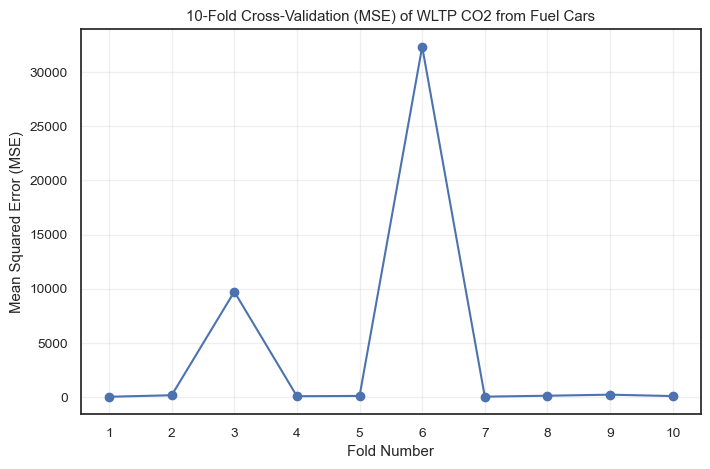

Exception ignored in: <function ResourceTracker.__del__ at 0x104c09bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1070ddbc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x102a85bc0>
Traceback (most recent call last

In [ ]:
# data validation for fuel cars, target variable: WLTP CO2
tenfold_dataValidation("WLTP CO2", data_fuel)

In [ ]:
# -- Reusable function for 10-fold CV and evaluation (regression task)--
def tenfold_dataValidation(target: str, data: pd.DataFrame, plot: bool = True, random_state: int = 42):
    assert target in data.columns, f"Target '{target}' not in dataframe."

    # Split X/y
    X = data.drop(columns=[target])
    y = data[target]

    # Encode categorical variables as dummy/one-hot columns
    X = pd.get_dummies(X, drop_first=True, dtype=float)

    # Simple numeric imputation (if there are any remaining NaNs)
    X = X.fillna(X.mean(numeric_only=True)).fillna(0)

    # 80 / 20 split, then 10 / 10 from the 20
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.20, 
                                                        random_state=random_state)
    X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.50, 
                                                    random_state=random_state)
    
    # Pipeline: scaling + linear regression before training
    pipe = make_pipeline(
        StandardScaler(),
        LogisticRegression()
    )

    # 10-fold CV on TRAIN ONLY (neg MSE -> MSE)
    kf = KFold(n_splits=10, shuffle=True, random_state=random_state)
    mse_scores = -cross_val_score(pipe, X_train, y_train, cv=kf,
                              scoring="neg_mean_squared_error", n_jobs=-1)
    print("10-fold CV MSE scores:", mse_scores.tolist())
    print("Mean MSE:", np.mean(mse_scores))

    # Auto labeling based on Fuel Type column
    if data["Fuel Type"].isin(fuel_types).any():
        data_label = "Fuel Cars"
    elif data["Fuel Type"].isin(hybrid_types).any():
        data_label = "Hybrid Cars"
    else:
        data_label = "Dataset"

    
    # --- Plot CV MSE ---
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, 11), mse_scores, marker='o', linestyle='-')
    plt.title(f'10-Fold Cross-Validation (MSE) of {target} from {data_label}')
    plt.xlabel('Fold Number'); plt.ylabel('Mean Squared Error (MSE)')
    plt.grid(alpha=0.3); plt.xticks(range(1, 11))
    plt.show()
 


10-fold CV MSE scores: [401.22222222222223, 369.1212121212121, 320.8181818181818, 358.8686868686869, 335.72727272727275, 407.0, 356.33673469387753, 359.8265306122449, 710.3163265306123, 416.5408163265306]
Mean MSE: 403.5777983920841


/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please als

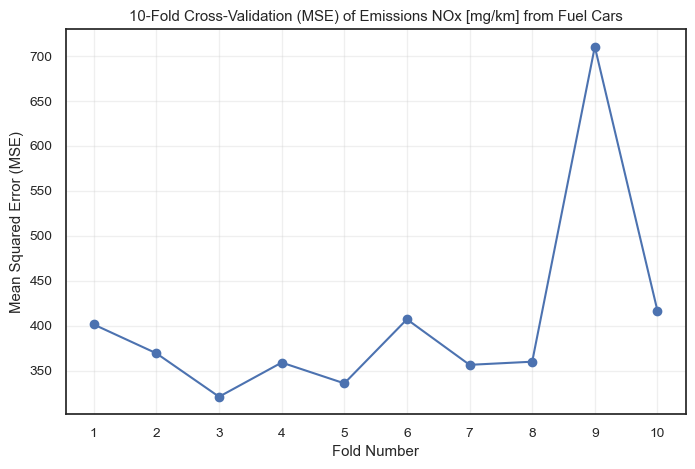

Validation MSE: 382.71774193548384
Test MSE: 289.3252032520325


Validation RMSE: 19.563173104981814
Test RMSE: 17.009562112295324


/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# data validation for fuel cars, target variable: Emissions NOx [mg/km]
tenfold_dataValidation("Emissions NOx [mg/km]", data_fuel)

*Hybrid car data*

/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please als

10-fold CV MSE scores: [596.6148148148148, 614.2222222222222, 110.21481481481482, 285.2888888888889, 447.0962962962963, 137.86666666666667, 93.48507462686567, 1040.7985074626865, 239.97761194029852, 646.9402985074627]
Mean MSE: 421.2505196241018


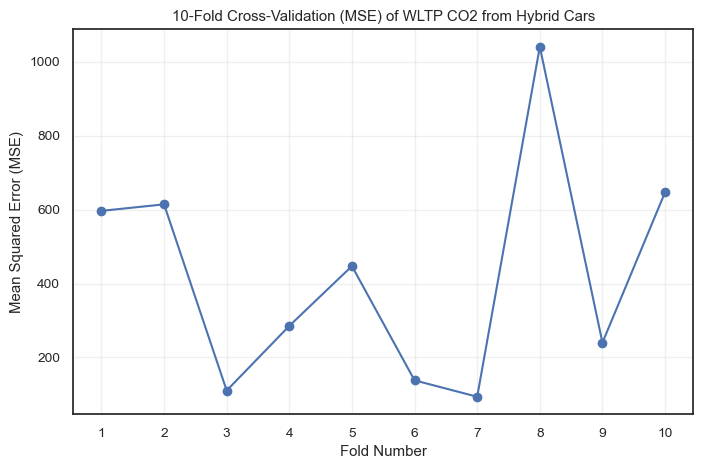

Validation MSE: 283.07100591715977
Test MSE: 402.0952380952381


Validation RMSE: 16.824714140726424
Test RMSE: 20.052312537341873


/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# data validation for hybrid cars, target variable: WLTP CO2
tenfold_dataValidation("WLTP CO2", data_hybrid)

/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please als

10-fold CV MSE scores: [42.65925925925926, 50.02962962962963, 55.49629629629629, 37.474074074074075, 61.67407407407408, 32.474074074074075, 63.559701492537314, 46.350746268656714, 44.014925373134325, 72.21641791044776]
Mean MSE: 50.59491984521835


/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please als

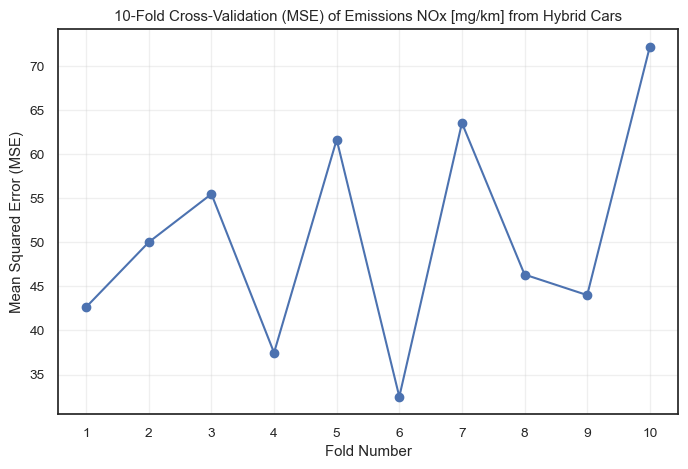

Validation MSE: 81.4733727810651
Test MSE: 18.345238095238095


Validation RMSE: 9.026260176898575
Test RMSE: 4.283134143969588


/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# data validation for hybrid cars, target variable: Emissions NOx [mg/km]
tenfold_dataValidation("Emissions NOx [mg/km]", data_hybrid)

In [ ]:
def feature_select_lasso(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    y_train,
    y_test,
    *,
    features: list | None = None,      # manually specify features; None = use all
    dataset_name: str = "Dataset",
    cv: int = 10,                      # 10-fold cross-validation
    random_state: int = 42,
    max_iter: int = 5000,
    lock_alpha: bool = False,          # set True to fix alpha instead of CV
    alpha_value: float | None = None,
    show_plots: bool = True
):
    """
    Lasso feature selection + 10-fold CV + overfitting checks + visualisations (RSS/MSE).
    Reuses existing train/test split.

    Returns
    -------
    results : dict         # metrics, alpha, selected transformed names, etc.
    pipeline : Pipeline    # fitted full pipeline (preprocessor + Lasso or LassoCV)
    """
    print(f"\n==================== {dataset_name.upper()} ====================")

    # --------------------- 1) Pick columns ----------------------
    if features is None:
        use_cols = X_train.columns.tolist()
    else:
        missing = [c for c in features if c not in X_train.columns]
        if missing:
            raise ValueError(f"Missing columns in X_train: {missing}")
        use_cols = list(dict.fromkeys(features))  # keep order, dedupe

    Xtr = X_train[use_cols].copy()
    Xte = X_test[use_cols].copy()

    # ------------------- 2) Preprocessing -----------------------
    numeric_cols = Xtr.select_dtypes(include=["float64", "int64"]).columns.tolist()
    cat_cols = [c for c in use_cols if c not in numeric_cols]  # dropped below

    numeric_pre = Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler())
    ])
    pre = ColumnTransformer([
        ("num", numeric_pre, numeric_cols),
        ("cat", "drop", cat_cols)
    ])

    # ------------------- 3) Model (with CV) ---------------------
    if lock_alpha:
        if alpha_value is None:
            raise ValueError("lock_alpha=True requires alpha_value.")
        model = Lasso(alpha=alpha_value, random_state=random_state, max_iter=max_iter)
    else:
        model = LassoCV(cv=cv, random_state=random_state, max_iter=max_iter)

    pipe = Pipeline([("pre", pre), ("model", model)])

    # ------------------- 4) Fit & Predict -----------------------
    pipe.fit(Xtr, y_train)
    yhat_tr = pipe.predict(Xtr)
    yhat_te = pipe.predict(Xte)

    # ------------------- 5) Metrics (RSS + MSE) -----------------
    rss_train = float(np.sum((y_train - yhat_tr) ** 2))
    rss_test  = float(np.sum((y_test  - yhat_te) ** 2))
    mse_train = float(mean_squared_error(y_train, yhat_tr))
    mse_test  = float(mean_squared_error(y_test,  yhat_te))

    chosen_alpha = (alpha_value if lock_alpha else pipe.named_steps["model"].alpha_)
    print(f"Using features ({len(use_cols)}): {use_cols}")
    print(f"Alpha (λ): {chosen_alpha:.6f}")
    print(f"Train RSS: {rss_train:.2f} | Test RSS: {rss_test:.2f}")
    print(f"Train MSE: {mse_train:.2f} | Test MSE: {mse_test:.2f}")

    # ------------------- 6) Overfitting checks ------------------
    # Ratio & gap checks
    ratio = rss_test / rss_train if rss_train > 0 else np.inf
    gap_pct = (mse_test - mse_train) / mse_train * 100 if mse_train > 0 else np.inf

    status = "OK"
    if ratio > 2.0 or gap_pct > 50:   # simple, sensible thresholds
        status = "Possible overfit (test error >> train error)"
    elif ratio < 0.6 and gap_pct < -20:
        status = "Possible underfit/anomaly (train error >> test error)"

    print(f"Overfit check — RSS ratio (test/train): {ratio:.2f}, MSE gap: {gap_pct:.1f}% → {status}")

    # ------------------- 7) Visualisations ----------------------
    if show_plots:
        cols = 3 if (not lock_alpha) else 2
        fig, axes = plt.subplots(1, cols, figsize=(5*cols, 4))
        if cols == 2:
            ax_cv, ax_scatter, ax_coef = None, axes[0], axes[1]
        else:
            ax_cv, ax_scatter, ax_coef = axes[0], axes[1], axes[2]

        # (a) CV curve (only when using LassoCV)
        if not lock_alpha and hasattr(model, "mse_path_"):
            mean_path = model.mse_path_.mean(axis=1)
            ax_cv.semilogx(model.alphas_, mean_path, marker='.')
            ax_cv.axvline(model.alpha_, linestyle='--')
            ax_cv.set_title(f"CV MSE vs Alpha ({cv}-fold)")
            ax_cv.set_xlabel("Alpha (λ)")
            ax_cv.set_ylabel("Mean CV MSE")

        # (b) Predicted vs Actual (test)
        ax_scatter.scatter(y_test, yhat_te)
        lo, hi = float(np.min(y_test)), float(np.max(y_test))
        ax_scatter.plot([lo, hi], [lo, hi], linestyle='--')
        ax_scatter.set_title("Predicted vs Actual (Test)")
        ax_scatter.set_xlabel("Actual WLTP CO2")
        ax_scatter.set_ylabel("Predicted WLTP CO2")

        # (c) Coefficients
        coef = pipe.named_steps["model"].coef_
        names = pipe.named_steps["pre"].get_feature_names_out()
        ax_coef.barh(names, coef)
        ax_coef.set_title("Lasso Coefficients")
        ax_coef.set_xlabel("Coefficient")
        plt.tight_layout()
        plt.show()

    # ------------------- 8) Package results ---------------------
    selected_transformed = list(pipe.named_steps["pre"].get_feature_names_out())
    results = {
        "dataset": dataset_name,
        "features_requested": use_cols,
        "features_transformed": selected_transformed,   # after preprocessing
        "alpha": float(chosen_alpha),
        "rss_train": rss_train,
        "rss_test": rss_test,
        "mse_train": mse_train,
        "mse_test": mse_test,
        "rss_ratio_test_train": float(ratio),
        "mse_gap_pct": float(gap_pct),
        "overfit_flag": status,
        "cv": (cv if not lock_alpha else None)
    }
    return results, pipe


==================== FUEL (ALL) ====================
Using features (18): ['Engine Capacity', 'Engine Power (PS)', 'WLTP Imperial Low', 'WLTP Imperial Medium', 'WLTP Imperial High', 'WLTP Imperial Extra High', 'WLTP Imperial Combined', 'WLTP Metric Low', 'WLTP Metric Medium', 'WLTP Metric High', 'WLTP Metric Extra High', 'WLTP Metric Combined', 'Emissions NOx [mg/km]', 'Manual or Automatic_Manual', 'Fuel Type_Petrol', 'Fuel Type_Petrol / LPG', 'Powertrain_Internal Combustion Engine (ICE)', 'Powertrain_Micro Hybrid']
Alpha (λ): 2.581182
Train RSS: 162296.21 | Test RSS: 13947.90
Train MSE: 164.60 | Test MSE: 113.40
Overfit check — RSS ratio (test/train): 0.09, MSE gap: -31.1% → Possible underfit/anomaly (train error >> test error)


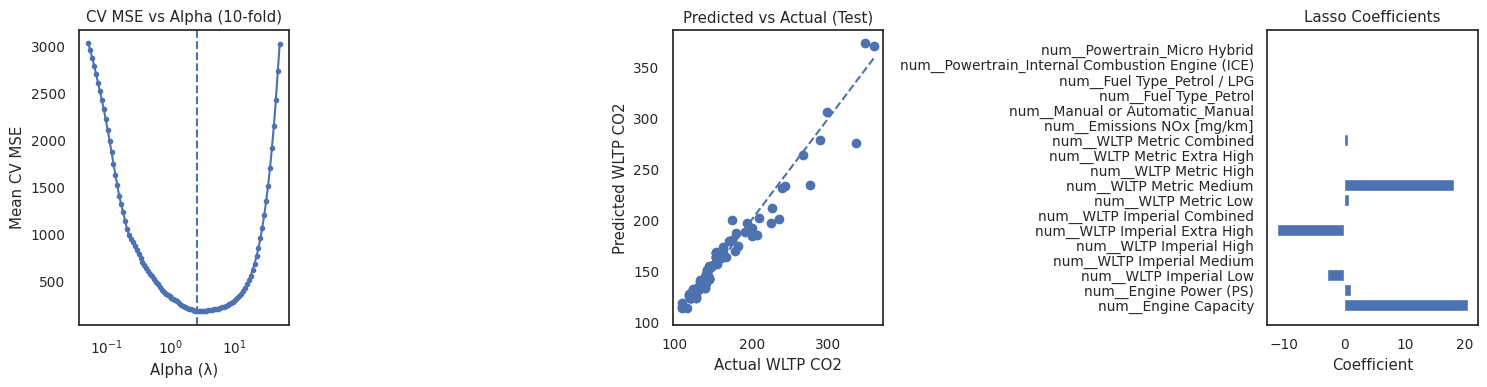

In [ ]:
# Example 1 — Fuel: manually pick columns
(X_train, X_val, X_test, y_train, y_val, y_test) = [
    data_split("WLTP CO2", data_fuel)[k] for k in
    ["X_train", "X_val", "X_test", "y_train", "y_val", "y_test"]
]

res_fuel_manual, pipe_fuel_manual = feature_select_lasso(
    X_train, X_test, y_train, y_test,
    features=None,
    dataset_name="Fuel (All)",
    cv=10
)


==================== FUEL (LESS) ====================
Using features (3): ['Engine Capacity', 'Engine Power (PS)', 'WLTP Imperial Combined']
Alpha (λ): 0.142993
Train RSS: 215575.74 | Test RSS: 21753.71
Train MSE: 218.64 | Test MSE: 176.86
Overfit check — RSS ratio (test/train): 0.10, MSE gap: -19.1% → OK


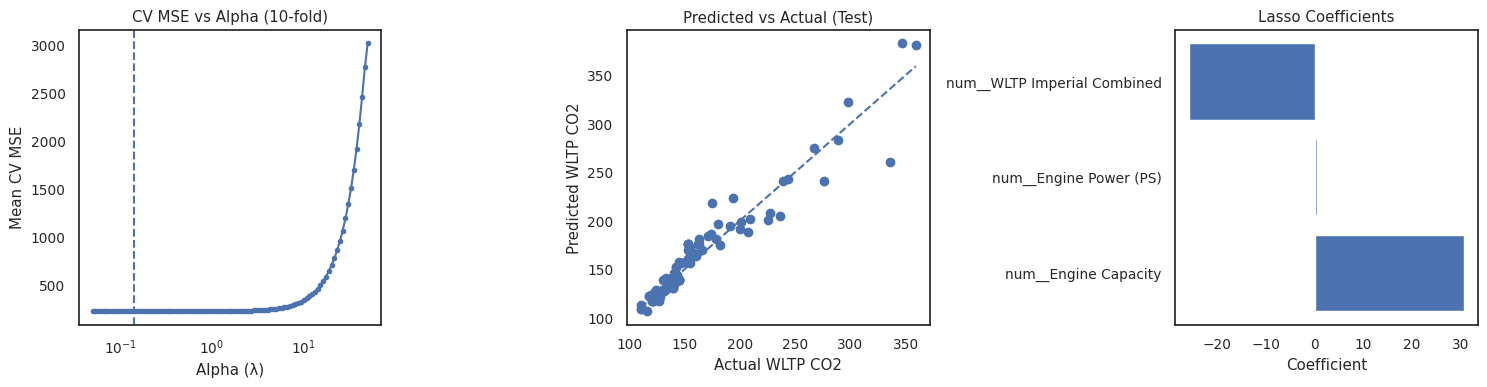

In [ ]:
# Example 1 — Fuel: manually pick columns
(X_train, X_val, X_test, y_train, y_val, y_test) = [
    data_split("WLTP CO2", data_fuel)[k] for k in
    ["X_train", "X_val", "X_test", "y_train", "y_val", "y_test"]
]
fuel_feats = ['Engine Capacity', 'Engine Power (PS)','WLTP Imperial Combined']
res_fuel_manual, pipe_fuel_manual = feature_select_lasso(
    X_train, X_test, y_train, y_test,
    features=fuel_feats,
    dataset_name="Fuel (Less)",
    cv=10
)


==================== HYBRID (ALL) ====================
Using features (22): ['Engine Capacity', 'Engine Power (PS)', 'WLTP Imperial Low', 'WLTP Imperial Medium', 'WLTP Imperial High', 'WLTP Imperial Extra High', 'WLTP Imperial Combined', 'WLTP Imperial Combined (Weighted)', 'WLTP Metric Low', 'WLTP Metric Medium', 'WLTP Metric High', 'WLTP Metric Extra High', 'WLTP Metric Combined', 'WLTP Metric Combined (Weighted)', 'Emissions NOx [mg/km]', 'Manual or Automatic_Electric - Not Applicable', 'Manual or Automatic_Manual', 'Fuel Type_Electricity / Petrol', 'Fuel Type_Petrol Electric', 'Powertrain_Mild Hybrid Electric Vehicle (MHEV)', 'Powertrain_Plug-in Hybrid Electric Vehicle (PHEV)', 'Powertrain_Range Extended Electric Vehicle (REEV)']
Alpha (λ): 0.050881
Train RSS: 387105.72 | Test RSS: 39654.67
Train MSE: 287.60 | Test MSE: 236.04
Overfit check — RSS ratio (test/train): 0.10, MSE gap: -17.9% → OK


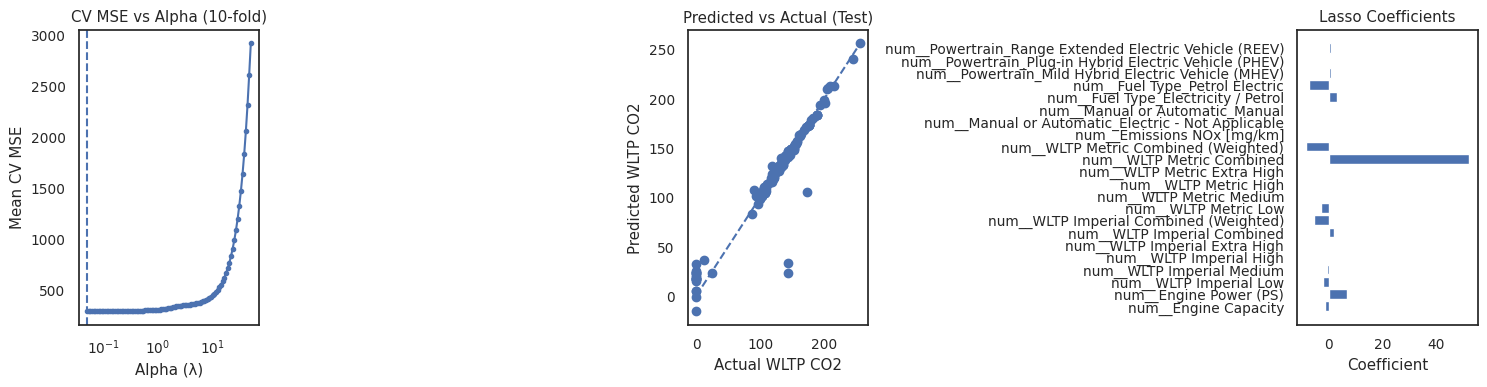

In [ ]:
# Example 2 — Hybrid: use all columns (features=None)
(X_train, X_val, X_test, y_train, y_val, y_test) = [
    data_split("WLTP CO2", data_hybrid)[k] for k in
    ["X_train", "X_val", "X_test", "y_train", "y_val", "y_test"]
]

res_hybrid_all, pipe_hybrid_all = feature_select_lasso(
    X_train, X_test, y_train, y_test,
    features=None,
    dataset_name="Hybrid (all)",
    cv=10
)


==================== FUEL (LESS FEATURES) ====================
Using features (3): ['Engine Capacity', 'Engine Power (PS)', 'WLTP Imperial Combined']
Alpha (λ): 0.021702
Train RSS: 2788884.26 | Test RSS: 349599.31
Train MSE: 2071.98 | Test MSE: 2080.95
Overfit check — RSS ratio (test/train): 0.13, MSE gap: 0.4% → OK


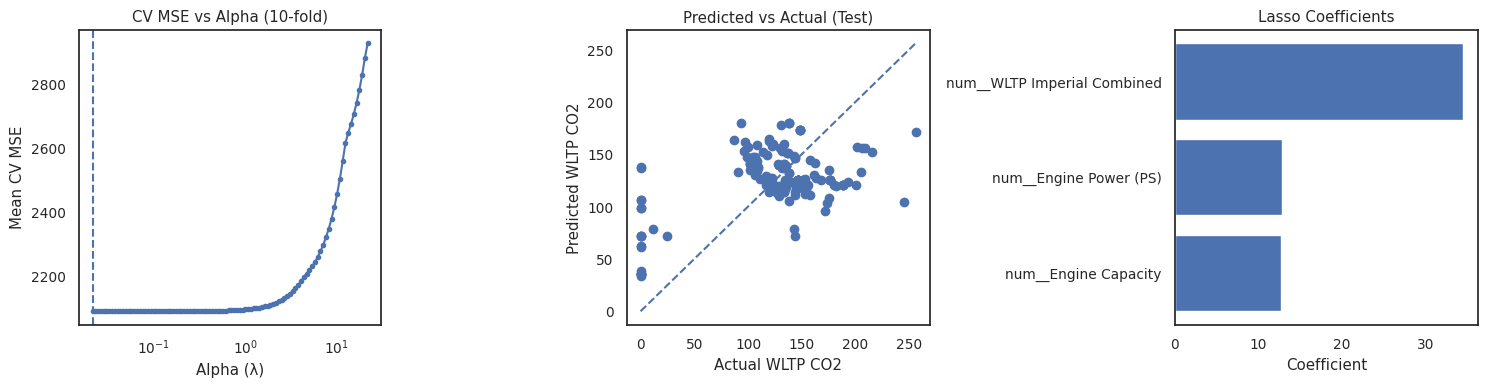

In [ ]:
# Example 3 — Lock alpha to a known value (e.g., from a previous CV run)
(X_train, X_val, X_test, y_train, y_val, y_test) = [
    data_split("WLTP CO2", data_hybrid)[k] for k in
    ["X_train", "X_val", "X_test", "y_train", "y_val", "y_test"]
]

res_fuel_locked, pipe_fuel_locked = feature_select_lasso(
    X_train, X_test, y_train, y_test,
    features=fuel_feats,
    dataset_name="Fuel (less features)",
    cv=10
    #lock_alpha=True,
    #alpha_value=0.02
)

## Neural Network - Regression Tasks

**Variables Selection**
The following variables should be used to develop neural networks model.


In [ ]:
#print current variables from the fuel cars dataset
print(data_fuel.columns)
print(data_fuel.shape)

Index(['Manual or Automatic', 'Engine Capacity', 'Fuel Type', 'Powertrain',
       'Engine Power (PS)', 'WLTP Imperial Low', 'WLTP Imperial Medium',
       'WLTP Imperial High', 'WLTP Imperial Extra High',
       'WLTP Imperial Combined', 'WLTP Metric Low', 'WLTP Metric Medium',
       'WLTP Metric High', 'WLTP Metric Extra High', 'WLTP Metric Combined',
       'WLTP CO2', 'Emissions NOx [mg/km]'],
      dtype='object')
(1233, 17)


Training RMSE: 47.91656112016815
Coefficient of determination (R²) on training data: 0.2474
Test RMSE: 43.59438590063248
Coefficient of determination (R²) on test data: 0.1527
Validation RMSE: 51.97374304866905
Coefficient of determination (R²) on  validation data: 0.2579


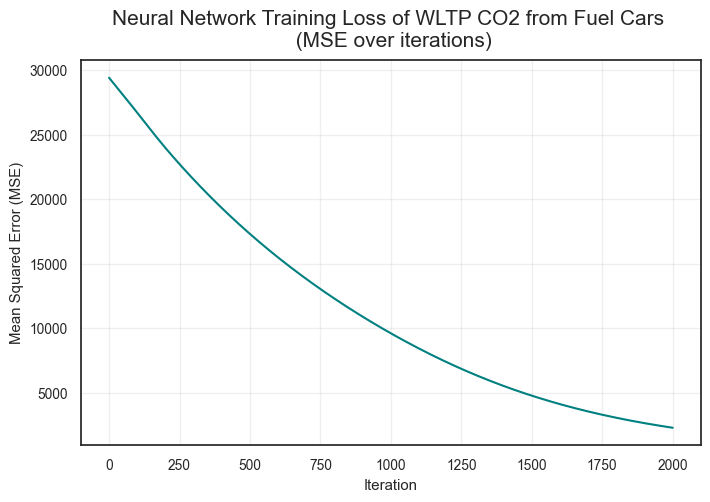

In [ ]:
# Reusable function for Neural Network regression task - simple 1 hidden layer NN
def neural_network_regression(target: str, data: pd.DataFrame, random_state: int = 42):
    assert target in data.columns, f"Target '{target}' not in dataframe."

    # Split X/y
    X = data.drop(columns=[target])
    y = data[target]

    features = X.columns.tolist()
    
    # Encode categorical variables as dummy/one-hot columns
    X = pd.get_dummies(X, drop_first=True, dtype=float)

    # Simple numeric imputation (if there are any remaining NaNs)
    X = X.fillna(X.mean(numeric_only=True)).fillna(0)
    X = X.dropna(axis=0, how='any')  # drop any columns that still have NaNs after mean imputation

    y = y.fillna(y.mean())
    y = y.dropna()

    # reshape y into a 2D array
    y = y.values.reshape(-1, 1)

    # 80 / 20 split, then 10 / 10 from the 20
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.20, 
                                                        random_state=random_state)
    X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.50, 
                                                    random_state=random_state)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    X_val_scaled = scaler.transform(X_val)

    # Define NN dimensions
    N = len(y_train) # number of samples
    D_in = X_train_scaled.shape[1] # number of features: 17
    D_out = 1 # number of outputs
    H = 20 # number of hidden neurons, based on number of features

    # Initialize weights
    W0 = normal(0, 0.1, size=(D_in, H))
    W1 = normal(0, 0.1, size=(H, D_out))

    # Training loop
    eta = 0.00005

    loss_history = []
    for i in range(2001):
        # forward pass
        
        ## Bias Terms
        b0 = np.zeros((1, H))
        b1 = np.zeros((1, 1))
        # z1 = X.dot(W0) + b0
        # a2 = a1.dot(W1) + b1

        z1 = X_train_scaled.dot(W0) + b0
        z1 = np.clip(z1, -500, 500)
        a1 = 1 / (1 + np.exp(-z1))
        a2 = a1.dot(W1) + b1
        Loss = np.mean((a2 - y_train) ** 2)
        loss_history.append(Loss)

        # # print loss every 100 iterations
        # if i % 100 == 0:
        #     print(f"Iteration {i}: Loss {Loss:.4f}")
    
        # backward pass
        da2 = 2.0 * (a2 - y_train)
        dW1 = a1.T.dot(da2) / N
        da1 = da2.dot(W1.T)
        dz1 = da1 * a1 * (1 - a1)
        dW0 = X_train_scaled.T.dot(dz1) / N
        
        # update
        W0 -= eta * dW0 # weights update for features
        W1 -= eta * dW1

    # Evaluate
    z1 = X_train_scaled.dot(W0)
    z1 = np.clip(z1, -500, 500)
    a1 = 1 / (1 + np.exp(-z1))
    y_pred = a1.dot(W1)

    # MSE and RMSE on training data
    print('Training RMSE:', np.sqrt(mean_squared_error(y_train, y_pred)))
    print('Coefficient of determination (R²) on training data:', round(r2_score(y_train, y_pred),4))

    # Evaluate on test set
    z1 = X_test_scaled.dot(W0)
    z1 = np.clip(z1, -500, 500)
    a1 = 1 / (1 + np.exp(-z1))
    y_test_pred = a1.dot(W1)

    print('Test RMSE:', np.sqrt(mean_squared_error(y_test, y_test_pred)))
    print('Coefficient of determination (R²) on test data:', round(r2_score(y_test, y_test_pred),4))

    # Evaluate on validation set
    z1 = X_val_scaled.dot(W0)
    z1 = np.clip(z1, -500, 500)
    a1 = 1 / (1 + np.exp(-z1))
    y_val_pred = a1.dot(W1)
    print('Validation RMSE:', np.sqrt(mean_squared_error(y_val, y_val_pred)))
    print('Coefficient of determination (R²) on  validation data:', round(r2_score(y_val, y_val_pred),4))


    # Auto labeling based on Fuel Type column
    if data["Fuel Type"].isin(fuel_types).any():
        data_label = "Fuel Cars"
    elif data["Fuel Type"].isin(hybrid_types).any():
        data_label = "Hybrid Cars"
    else:
        data_label = "Dataset"


    #Visualise the MSE
    plt.figure(figsize=(8,5))
    plt.plot(loss_history, color='teal')
    plt.title(f"Neural Network Training Loss of {target} from {data_label} \n (MSE over iterations)",
              fontsize = 15, pad = 10)
    plt.xlabel("Iteration")
    plt.ylabel("Mean Squared Error (MSE)")
    plt.grid(alpha=0.3)
    plt.show()

    # # Return the weights and features of the model
    # return{
    #     "features": features,
    #     "W0": W0
    #     }

# Neural Network regression for fuel cars, target variable: WLTP CO2
neural_network_regression("WLTP CO2", data_fuel)

Training RMSE: 17.010478910829278
Coefficient of determination (R²) on training data: -0.1798
Test RMSE: 13.097453148671184
Coefficient of determination (R²) on test data: -0.1461
Validation RMSE: 14.537809260655937
Coefficient of determination (R²) on  validation data: -0.2386


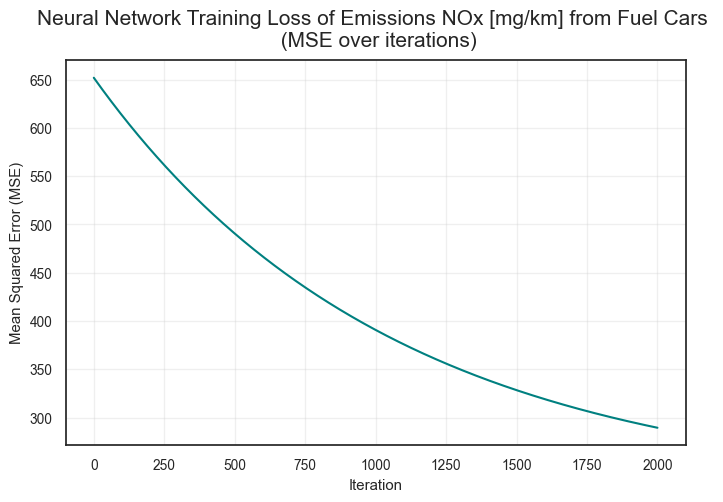

In [ ]:
# Neural Network regression for fuel cars, target variable: Emissions NOx [mg/km]
neural_network_regression("Emissions NOx [mg/km]", data_fuel)

Training RMSE: 30.791692643903097
Coefficient of determination (R²) on training data: 0.6767
Test RMSE: 26.76080853317933
Coefficient of determination (R²) on test data: 0.7422
Validation RMSE: 25.044018949191784
Coefficient of determination (R²) on  validation data: 0.6901


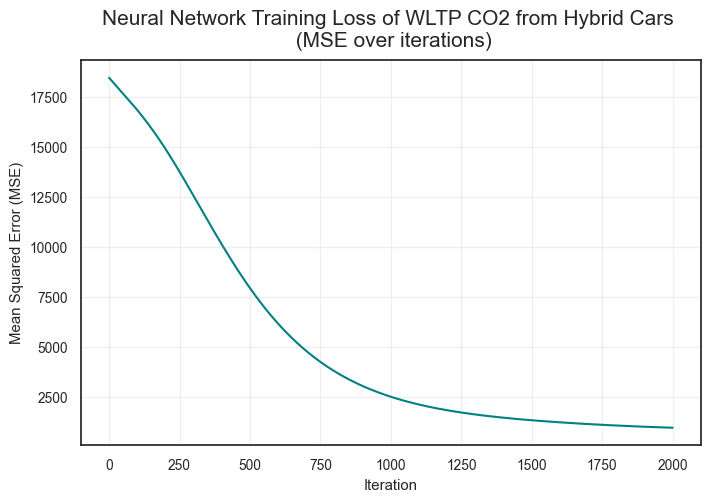

In [ ]:
# Neural Network regression for hybrid cars, target variable: WLTP CO2
neural_network_regression("WLTP CO2", data_hybrid)

Training RMSE: 9.015982734801371
Coefficient of determination (R²) on training data: -0.0799
Test RMSE: 6.760756027992076
Coefficient of determination (R²) on test data: -0.0136
Validation RMSE: 10.540609744475459
Coefficient of determination (R²) on  validation data: -0.1165


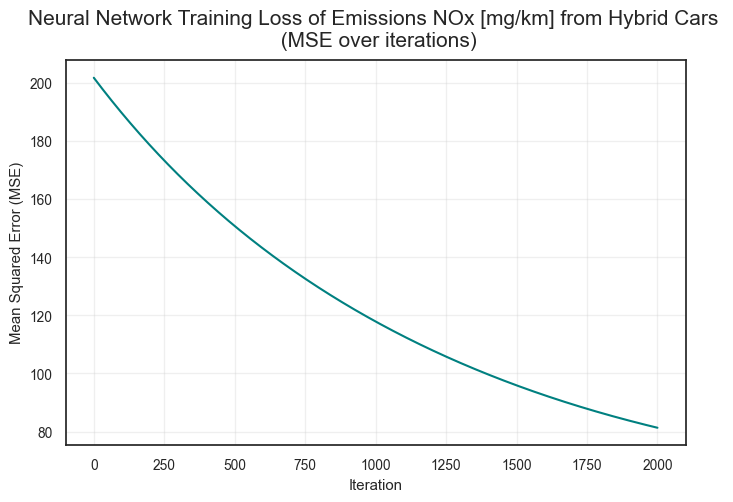

In [ ]:
# Neural Network regression for hybrid cars, target variable: Emissions NOx [mg/km]
neural_network_regression("Emissions NOx [mg/km]", data_hybrid)

Training RMSE: 49.05771660639104
Coefficient of determination (R²) on training data: 0.2111
Test RMSE: 44.71852507101844
Coefficient of determination (R²) on test data: 0.1085
Validation RMSE: 53.04422067444268
Coefficient of determination (R²) on  validation data: 0.227


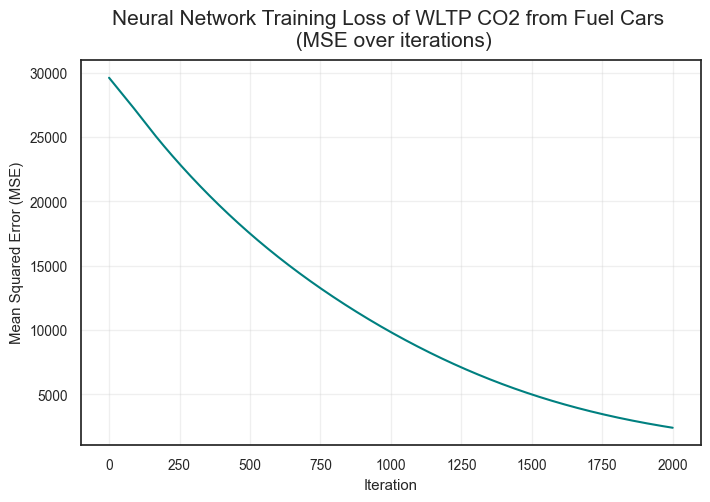

TypeError: 'NoneType' object is not subscriptable

In [ ]:
#Examine feature importance from the neural network regression for fuel cars, target variable: WLTP CO2

res = neural_network_regression("WLTP CO2", data_fuel);

# from your Regressor() output
W0 = res["W0"]                    # shape: [n_features, H]
features = res["features"]
imp = np.mean(np.abs(W0), axis=1)

print("W0 shape:", W0.shape)
print("Number of features:", len(features))

# Ensure they match in length
min_len = min(len(features), len(imp))
features = features[:min_len]
imp = imp[:min_len]

imp_df = pd.DataFrame({"Feature": features, "Importance": imp})
imp_df = imp_df.sort_values(by="Importance", ascending=True)



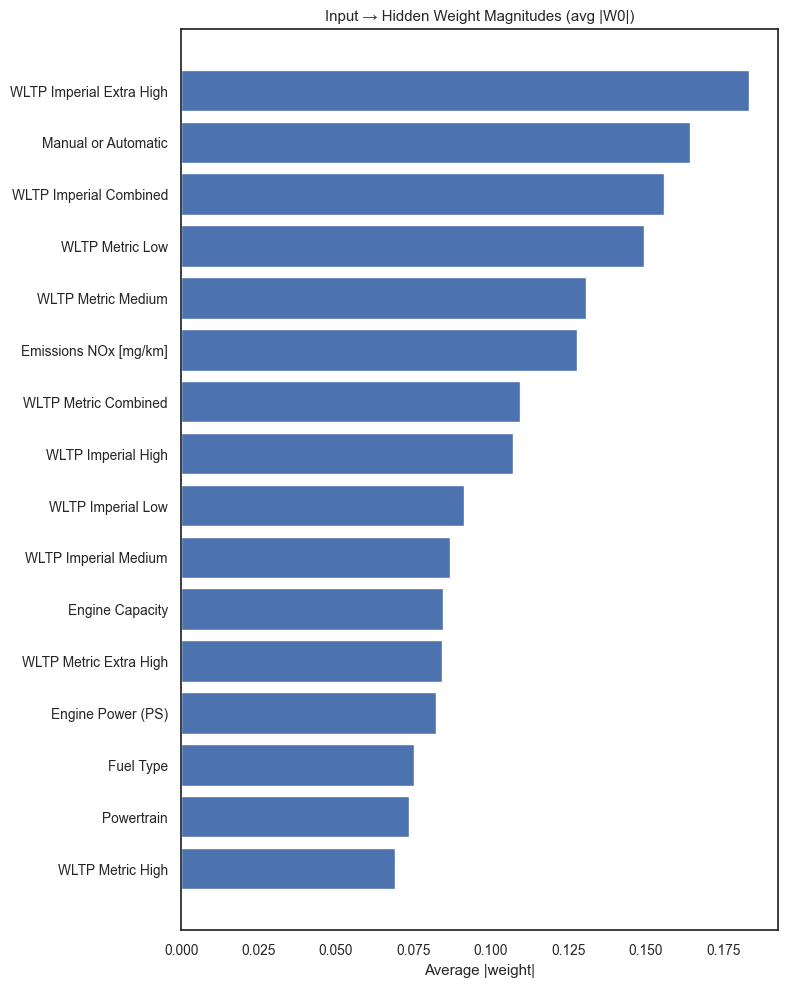

In [ ]:
# importance = average absolute incoming weight to hidden layer
plt.figure(figsize=(8, 10))
plt.barh(imp_df["Feature"], imp_df["Importance"])
plt.title("Input → Hidden Weight Magnitudes (avg |W0|)")
plt.xlabel("Average |weight|")
plt.tight_layout()
plt.show()

Training RMSE: 47.263419324078576
Coefficient of determination (R²) on training data: 0.2678
Test RMSE: 38.53346412637326
Coefficient of determination (R²) on test data: 0.338
Validation RMSE: 52.36187042841957
Coefficient of determination (R²) on  validation data: 0.2468


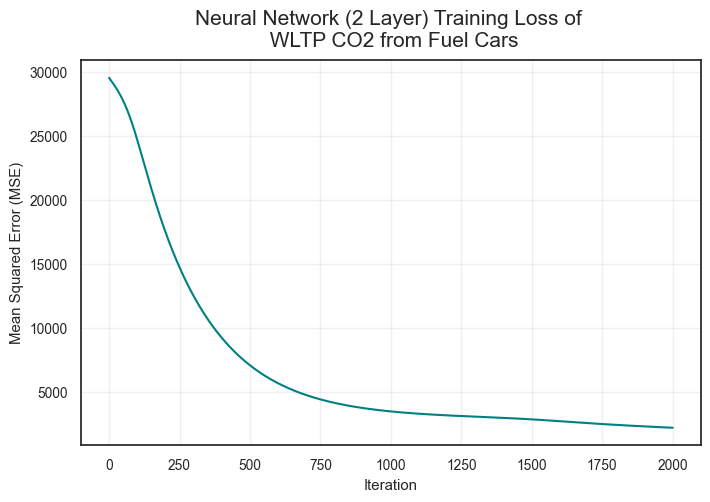

In [ ]:
# Reusable function for Neural Network regression task - 2 hidden layer NN
def neural_network_regression_2hidden(target: str, data: pd.DataFrame, random_state: int = 42):
    assert target in data.columns, f"Target '{target}' not in dataframe."

    splits = data_split(target, data)

    X_train = splits["X_train"]
    X_val   = splits["X_val"]
    X_test  = splits["X_test"]
    y_train = splits["y_train"]   
    y_val   = splits["y_val"]
    y_test  = splits["y_test"]      

    # Flatten target arrays
    y_train = y_train.values.reshape(-1, 1)
    y_val   = y_val.values.reshape(-1, 1)
    y_test  = y_test.values.reshape(-1, 1)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    X_val_scaled = scaler.transform(X_val)

    # Define NN dimensions
    N = len(y_train) # number of samples
    D_in = X_train_scaled.shape[1] # number of features
    D_out = 1 # number of outputs
    H1 = 30 # number of hidden neurons in hidden layer 1
    H2 = 20 # number of hidden neurons in hidden layer 2

    # -- Initialize weights
    # Layer 1: input -> hidden1
    W0 = normal(0, 0.1, size=(D_in, H1))
    b0 = np.zeros((1, H1))

    # Layer 2: hidden1 -> hidden2
    W1 = normal(0, 0.1, size=(H1, H2))
    b1 = np.zeros((1, H2))

    # Output: hidden2 -> output
    W2 = normal(0, 0.1, size=(H2, D_out))
    b2 = np.zeros((1, D_out))
    
    # Training loop
    eta = 0.00005

    loss_history = []
    for i in range(2001):
        # ---- forward pass ----
        ## Layer 1
        z1 = X_train_scaled.dot(W0) + b0
        z1 = np.clip(z1, -500, 500) 
        a1 = 1.0 / (1.0 + np.exp(-z1)) # sigmoid

        # Layer 2
        z2 = a1.dot(W1) + b1
        z2 = np.clip(z2, -500, 500)
        a2 = 1.0 / (1.0 + np.exp(-z2)) # sigmoid

        # Output (linear)
        y_hat = a2.dot(W2) + b2

        # Loss (MSE)
        Loss = np.mean((y_hat - y_train) ** 2)
        loss_history.append(float(Loss))

        # ---- backward pass ----
        # dLoss/dy_hat = 2*(y_hat - y) / N
        dy = (2.0 / N) * (y_hat - y_train)

        # Gradients for output layer (a2 -> y_hat)
        dW2 = a2.T.dot(dy)     
        db2 = np.sum(dy, axis=0, keepdims=True) 

        # Backprop into hidden2
        da2 = dy.dot(W2.T)                        
        dz2 = da2 * a2 * (1.0 - a2)               
        dW1 = a1.T.dot(dz2)                       
        db1 = np.sum(dz2, axis=0, keepdims=True)  

        # Backprop into hidden1
        da1 = dz2.dot(W1.T)                       
        dz1 = da1 * a1 * (1.0 - a1)               
        dW0 = X_train_scaled.T.dot(dz1)           
        db0 = np.sum(dz1, axis=0, keepdims=True) 

        # ---- update parameters ----
        W2 -= eta * dW2
        b2 -= eta * db2
        W1 -= eta * dW1
        b1 -= eta * db1
        W0 -= eta * dW0
        b0 -= eta * db0

    # # Evaluate
    # z1 = X_train_scaled.dot(W0)
    # z1 = np.clip(z1, -500, 500)
    # a1 = 1 / (1 + np.exp(-z1))
    # y_pred = a1.dot(W2)

    # Evaluate on training set
    z1_ = X_train_scaled.dot(W0) + b0
    z1_ = np.clip(z1_, -500, 500)
    a1_ = 1.0 / (1.0 + np.exp(-z1_))
    z2_ = a1_.dot(W1) + b1
    z2_ = np.clip(z2_, -500, 500)
    a2_ = 1.0 / (1.0 + np.exp(-z2_))
    y_pred = a2_.dot(W2) + b2

    # MSE and RMSE on training data
    print('Training RMSE:', np.sqrt(mean_squared_error(y_train, y_pred)))
    print('Coefficient of determination (R²) on training data:', round(r2_score(y_train, y_pred),4))

    # Evaluate on test set
    z1_ = X_test_scaled.dot(W0) + b0
    z1_ = np.clip(z1_, -500, 500)
    a1_ = 1.0 / (1.0 + np.exp(-z1_))
    z2_ = a1_.dot(W1) + b1
    z2_ = np.clip(z2_, -500, 500)
    a2_ = 1.0 / (1.0 + np.exp(-z2_))
    y_test_pred = a2_.dot(W2) + b2

    print('Test RMSE:', np.sqrt(mean_squared_error(y_test, y_test_pred)))
    print('Coefficient of determination (R²) on test data:', round(r2_score(y_test, y_test_pred),4))

    # Evaluate on validation set
    z1_ = X_val_scaled.dot(W0) + b0
    z1_ = np.clip(z1_, -500, 500)
    a1_ = 1.0 / (1.0 + np.exp(-z1_))
    z2_ = a1_.dot(W1) + b1
    z2_ = np.clip(z2_, -500, 500)
    a2_ = 1.0 / (1.0 + np.exp(-z2_))
    y_val_pred = a2_.dot(W2) + b2
    
    print('Validation RMSE:', np.sqrt(mean_squared_error(y_val, y_val_pred)))
    print('Coefficient of determination (R²) on  validation data:', round(r2_score(y_val, y_val_pred),4))


    # Auto labeling based on Fuel Type column
    if data["Fuel Type"].isin(fuel_types).any():
        data_label = "Fuel Cars"
    elif data["Fuel Type"].isin(hybrid_types).any():
        data_label = "Hybrid Cars"
    else:
        data_label = "Dataset"


    #Visualise the MSE
    plt.figure(figsize=(8,5))
    plt.plot(loss_history, color='teal')
    plt.title(f"Neural Network (2 Layer) Training Loss of \n {target} from {data_label}",
              fontsize = 15, pad = 10)
    plt.xlabel("Iteration")
    plt.ylabel("Mean Squared Error (MSE)")
    plt.grid(alpha=0.3)
    plt.show()

    # # Return the weights and features of the model
    # return{
    #     "features": features,
    #     "W0": W0
    #     }

# Neural Network regression for fuel cars, target variable: WLTP CO2
neural_network_regression_2hidden("WLTP CO2", data_fuel)

In [ ]:
# Reusable function for Neural Network regression task - 3 hidden layer NN
def neural_network_regression_3hidden(target: str, data: pd.DataFrame, random_state: int = 42):
    assert target in data.columns, f"Target '{target}' not in dataframe."

    # Split X/y
    X = data.drop(columns=[target])
    y = data[target]

    features = X.columns.tolist()
    
    # Encode categorical variables as dummy/one-hot columns
    X = pd.get_dummies(X, drop_first=True, dtype=float)

    # Simple numeric imputation (if there are any remaining NaNs)
    X = X.fillna(X.mean(numeric_only=True)).fillna(0)
    X = X.dropna(axis=0, how='any')  # drop any columns that still have NaNs after mean imputation

    y = y.fillna(y.mean())
    y = y.dropna()

    # reshape y into a 2D array
    y = y.values.reshape(-1, 1)

    # 80 / 20 split, then 10 / 10 from the 20
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.20, 
                                                        random_state=random_state)
    X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.50, 
                                                    random_state=random_state)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    X_val_scaled = scaler.transform(X_val)

    # Define NN dimensions
    N = len(y_train) # number of samples
    D_in = X_train_scaled.shape[1] # number of features
    D_out = 1 # number of outputs
    H1 = 30 # number of hidden neurons in hidden layer 1
    H2 = 20 # number of hidden neurons in hidden layer 2

    # -- Initialize weights
    # Layer 1: input -> hidden1
    W0 = normal(0, 0.1, size=(D_in, H1))
    b0 = np.zeros((1, H1))

    # Layer 2: hidden1 -> hidden2
    W1 = normal(0, 0.1, size=(H1, H2))
    b1 = np.zeros((1, H2))

    # Output: hidden2 -> output
    W2 = normal(0, 0.1, size=(H2, D_out))
    b2 = np.zeros((1, D_out))
    
    # Training loop
    eta = 0.00005

    loss_history = []
    for i in range(2001):
        # ---- forward pass ----
        ## Layer 1
        z1 = X_train_scaled.dot(W0) + b0
        z1 = np.clip(z1, -500, 500) 
        a1 = 1.0 / (1.0 + np.exp(-z1)) # sigmoid

        # Layer 2
        z2 = a1.dot(W1) + b1
        z2 = np.clip(z2, -500, 500)
        a2 = 1.0 / (1.0 + np.exp(-z2)) # sigmoid

        # Output (linear)
        y_hat = a2.dot(W2) + b2

        # Loss (MSE)
        Loss = np.mean((y_hat - y_train) ** 2)
        loss_history.append(float(Loss))

        # ---- backward pass ----
        # dLoss/dy_hat = 2*(y_hat - y) / N
        dy = (2.0 / N) * (y_hat - y_train)

        # Gradients for output layer (a2 -> y_hat)
        dW2 = a2.T.dot(dy)     
        db2 = np.sum(dy, axis=0, keepdims=True) 

        # Backprop into hidden2
        da2 = dy.dot(W2.T)                        
        dz2 = da2 * a2 * (1.0 - a2)               
        dW1 = a1.T.dot(dz2)                       
        db1 = np.sum(dz2, axis=0, keepdims=True)  

        # Backprop into hidden1
        da1 = dz2.dot(W1.T)                       
        dz1 = da1 * a1 * (1.0 - a1)               
        dW0 = X_train_scaled.T.dot(dz1)           
        db0 = np.sum(dz1, axis=0, keepdims=True) 

        # ---- update parameters ----
        W2 -= eta * dW2
        b2 -= eta * db2
        W1 -= eta * dW1
        b1 -= eta * db1
        W0 -= eta * dW0
        b0 -= eta * db0

    # # Evaluate
    # z1 = X_train_scaled.dot(W0)
    # z1 = np.clip(z1, -500, 500)
    # a1 = 1 / (1 + np.exp(-z1))
    # y_pred = a1.dot(W2)

    # Evaluate on training set
    z1_ = X_train_scaled.dot(W0) + b0
    z1_ = np.clip(z1_, -500, 500)
    a1_ = 1.0 / (1.0 + np.exp(-z1_))
    z2_ = a1_.dot(W1) + b1
    z2_ = np.clip(z2_, -500, 500)
    a2_ = 1.0 / (1.0 + np.exp(-z2_))
    y_pred = a2_.dot(W2) + b2

    # MSE and RMSE on training data
    print('Training RMSE:', np.sqrt(mean_squared_error(y_train, y_pred)))
    print('Coefficient of determination (R²) on training data:', round(r2_score(y_train, y_pred),4))

    # Evaluate on test set
    z1_ = X_test_scaled.dot(W0) + b0
    z1_ = np.clip(z1_, -500, 500)
    a1_ = 1.0 / (1.0 + np.exp(-z1_))
    z2_ = a1_.dot(W1) + b1
    z2_ = np.clip(z2_, -500, 500)
    a2_ = 1.0 / (1.0 + np.exp(-z2_))
    y_test_pred = a2_.dot(W2) + b2

    print('Test RMSE:', np.sqrt(mean_squared_error(y_test, y_test_pred)))
    print('Coefficient of determination (R²) on test data:', round(r2_score(y_test, y_test_pred),4))

    # Evaluate on validation set
    z1_ = X_val_scaled.dot(W0) + b0
    z1_ = np.clip(z1_, -500, 500)
    a1_ = 1.0 / (1.0 + np.exp(-z1_))
    z2_ = a1_.dot(W1) + b1
    z2_ = np.clip(z2_, -500, 500)
    a2_ = 1.0 / (1.0 + np.exp(-z2_))
    y_val_pred = a2_.dot(W2) + b2
    
    print('Validation RMSE:', np.sqrt(mean_squared_error(y_val, y_val_pred)))
    print('Coefficient of determination (R²) on  validation data:', round(r2_score(y_val, y_val_pred),4))


    # Auto labeling based on Fuel Type column
    if data["Fuel Type"].isin(fuel_types).any():
        data_label = "Fuel Cars"
    elif data["Fuel Type"].isin(hybrid_types).any():
        data_label = "Hybrid Cars"
    else:
        data_label = "Dataset"


    #Visualise the MSE
    plt.figure(figsize=(8,5))
    plt.plot(loss_history, color='teal')
    plt.title(f"Neural Network (2 Layer) Training Loss of {target} from {data_label} \n (MSE over iterations)",
              fontsize = 15, pad = 10)
    plt.xlabel("Iteration")
    plt.ylabel("Mean Squared Error (MSE)")
    plt.grid(alpha=0.3)
    plt.show()

    # # Return the weights and features of the model
    # return{
    #     "features": features,
    #     "W0": W0
    #     }

# Neural Network regression for fuel cars, target variable: WLTP CO2
neural_network_regression_2hidden("WLTP CO2", data_fuel)

Training RMSE: 48.06894270209288
Coefficient of determination (R²) on training data: 0.2426
Test RMSE: 43.8254626607203
Coefficient of determination (R²) on test data: 0.1437
Validation RMSE: 52.39483902741688
Coefficient of determination (R²) on  validation data: 0.2458


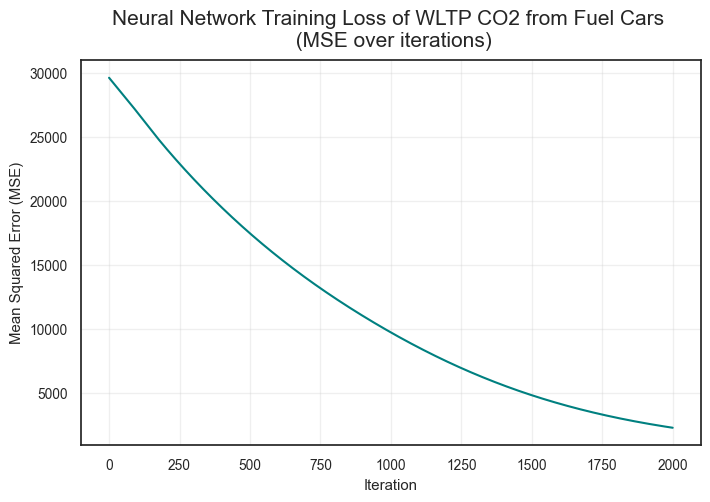

Training RMSE: 47.16592839445747
Coefficient of determination (R²) on training data: 0.2708
Test RMSE: 38.45502289091125
Coefficient of determination (R²) on test data: 0.3407
Validation RMSE: 52.2653324984031
Coefficient of determination (R²) on  validation data: 0.2495


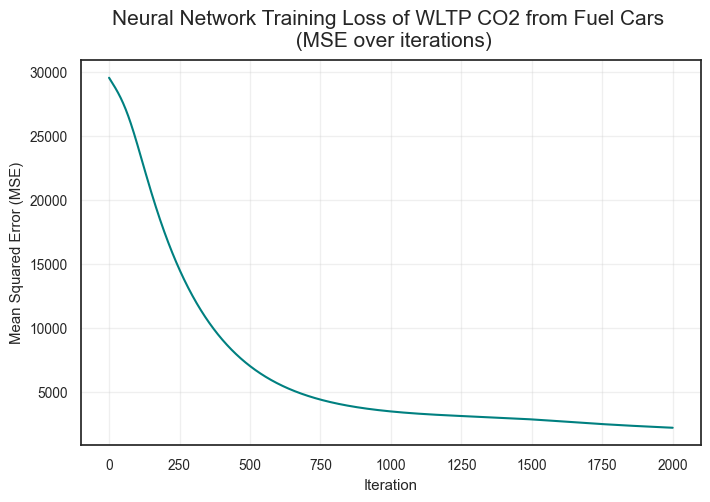

In [ ]:
# -- Evaluation of neural network model based on numbers of layers --
neural_network_regression("WLTP CO2", data_fuel)
neural_network_regression_2hidden("WLTP CO2", data_fuel)